# Heavy Equipment Selling Price Prediction

## 1. Problem statement

The goal of this project is to predict the selling price (`TargetValue`) of heavy equipment. Each row in the data describes one transaction of a machine: asset and configuration identifiers, specification attributes (model series, size class, physical specifications), usage information (manufacture year, operating hours), and transaction context (date, region, vendor).

- **Task type:** supervised regression.
- **Target:** `TargetValue`, the transaction price of the equipment.
- **Evaluation metric:** RMSLE (Root Mean Squared Logarithmic Error):

$$\text{RMSLE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}\Big(\log(1+p_i) - \log(1+y_i)\Big)^2}$$

RMSLE penalizes relative error rather than absolute error, so the model must be accurate across the whole price range, not only on expensive machines. It also means that optimizing squared error on `log1p(price)` is mathematically equivalent to optimizing the competition metric directly.


## Approach

1. **Exploratory Data Analysis** - target distribution, missingness, univariate and bivariate analysis of key drivers, temporal patterns, and resale structure; each finding is tied to a concrete downstream decision.
2. **Systematic preprocessing** with reusable custom functions applied jointly to train and test data, with a strict no-leakage policy.
3. **Feature engineering** (depreciation, utilization intensity, prior-sale history, market trend) followed by feature-importance analysis.
4. **Three model families** - LightGBM and XGBoost (gradient-boosted trees) and Ridge (regularized linear model), six models in total - with hyperparameter tuning under 5-fold cross-validation.
5. **Performance and error analysis**, non-negative ensemble weight optimization, calibration, and a clipped final submission.

The final calibrated blend in this notebook is my best performing model (Kaggle leaderboard RMSLE **0.18673**).

## 2. Setup and data loading

**Libraries.** The solution uses only numpy, pandas, scikit-learn, XGBoost, LightGBM, SciPy, and matplotlib. `StratifiedKFold` provides the cross-validation scheme, `FeatureHasher` encodes high-cardinality categoricals, `RidgeCV` tunes the Ridge regularization strength, and `scipy.optimize.minimize` tunes the ensemble weights and calibration.

**Constants.** `REF_YEAR = 2024` is the reference point from which all "age" features are computed. `N_SPLITS = 5` sets the number of CV folds, and `RANDOM_STATE` plus `np.random.seed` make every stochastic step reproducible.

**Loading.** Both CSVs are read with `low_memory=False` so pandas infers dtypes consistently for mixed-type columns instead of guessing chunk by chunk.

In [1]:
import numpy as np
import pandas as pd
import re
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_log_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.feature_extraction import FeatureHasher
from scipy.optimize import minimize
from scipy.sparse import csr_matrix, hstack
import xgboost as xgb
import lightgbm as lgb

TARGET = 'TargetValue'
ID_COL = 'TransactionID'
REF_YEAR = 2024
N_SPLITS = 5
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

train = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv', low_memory=False)
test = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv', low_memory=False)

print(f"Train shape: {train.shape}, Test shape: {test.shape}")

Train shape: (138701, 50), Test shape: (15000, 49)


### Looking at the data

Inspect the first rows and the dtype breakdown. This dataset mixes numeric columns (years, meters) with categorical columns that carry embedded numbers, units, and composite codes so the preprocessing stage needs custom parsing functions rather than encoding alone.

In [2]:
print("First rows of the training data:")
display(train.head(3))

print("Column dtype breakdown:")
print(train.dtypes.astype(str).value_counts().to_string())

First rows of the training data:


,TransactionID,TargetValue,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,...,col20,col21,col22,col23,col24,col25,col27,col28,col29,col30
0,1139309,57000.0,117665,88,ACH138,GTX,1997,4640.0,Low,2005-03-26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139316,26500.0,1001282,4616,ACH138,GTX,2005,508.0,Low,2009-12-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1139317,21000.0,772709,1948,ACH138,GTX,1994,11540.0,High,2005-08-26,...,Steel,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN


Column dtype breakdown:
object     44
int64       4
float64     2


## 3. Target transformation

1. **Log transform.** `y = log1p(TargetValue)`. Because RMSLE on raw prices equals RMSE on `log1p` prices, every model trained with a squared-error loss on `y` is directly optimizing the competition metric. It also tames the heavy right skew typical of price data, which stabilizes gradient-based training.
2. **Winsorizing the log target.** The log target is clipped to its 0.05 and 99.95 percentiles. A handful of extreme prices would otherwise dominate the gradients of every boosting iteration. Clipping them costs almost nothing in metric terms but noticeably stabilizes training.
3. **`float32` storage** keeps memory usage low, which matters once the feature count grows into the hundreds.

`test_ids`, `n_train` and `n_test` are stored here so the combined train+test frame built later can always be split back unambiguously.

In [3]:
y_raw = train[TARGET].astype(float).values
y_log = np.log1p(y_raw)
y_log = np.clip(y_log, np.percentile(y_log, 0.05), np.percentile(y_log, 99.95))
y = y_log.astype(np.float32)

test_ids = test[ID_COL].values
n_train = len(train)
n_test = len(test)

## 4. Exploratory Data Analysis (EDA)

In order:

1. **Target distribution** - raw vs log-transformed.
2. **Missingness** - which columns are empty or constant.
3. **Univariate analysis** - distributions of the key numeric drivers and the main categorical columns.
4. **Bivariate analysis** - how price moves with manufacture year and operating hours, and which numeric columns correlate most with the target.
5. **Temporal patterns** - market price trend over time.
6. **Resale structure** - how often the same asset is sold repeatedly.

### 4.1 Target distribution

Compare the raw target with its `log1p` transform and print summary statistics and skewness for both.

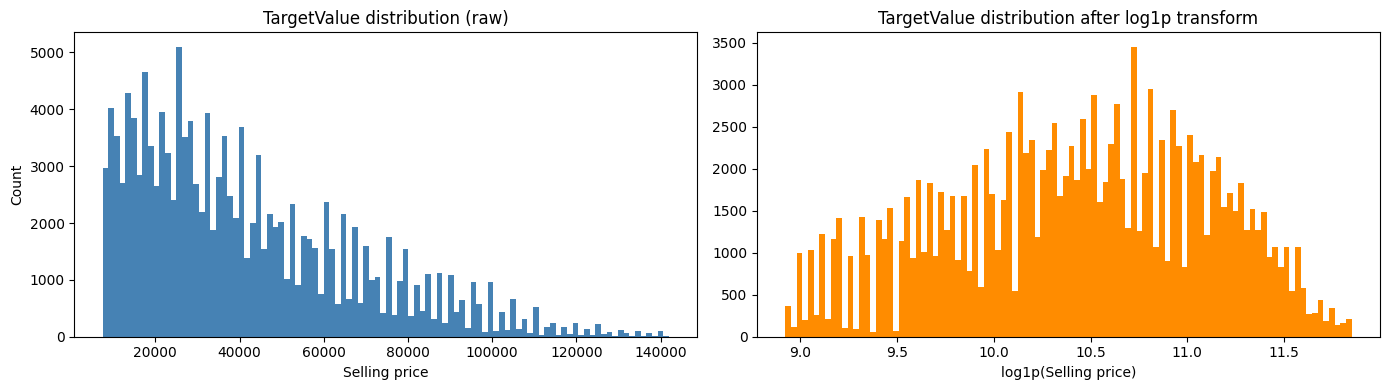

count    138701.00
mean      41521.87
std       26361.13
min        7500.00
25%       20500.00
50%       35000.00
75%       57000.00
max      142000.00
Skewness raw: 0.97, after log1p: -0.20


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(y_raw, bins=100, color='steelblue')
axes[0].set_title('TargetValue distribution (raw)')
axes[0].set_xlabel('Selling price')
axes[0].set_ylabel('Count')
axes[1].hist(y, bins=100, color='darkorange')
axes[1].set_title('TargetValue distribution after log1p transform')
axes[1].set_xlabel('log1p(Selling price)')
plt.tight_layout()
plt.show()

print(pd.Series(y_raw).describe().round(2).to_string())
print(f"Skewness raw: {pd.Series(y_raw).skew():.2f}, after log1p: {pd.Series(y).skew():.2f}")

**Insights and influence on the pipeline.** Prices span several orders of magnitude and are strongly right-skewed, while the log-transformed target is close to symmetric with much lower skew. This confirms the decision in Section 3: training on `log1p(TargetValue)` is the right way to optimize RMSLE, and it also justifies clipping the final submission to the observed target range - a model evaluated on relative error should not extrapolate into price regions the market never visits.

### 4.2 Missing values and constant columns

Rank columns by missing fraction and count how many columns are essentially empty or carry a single value.

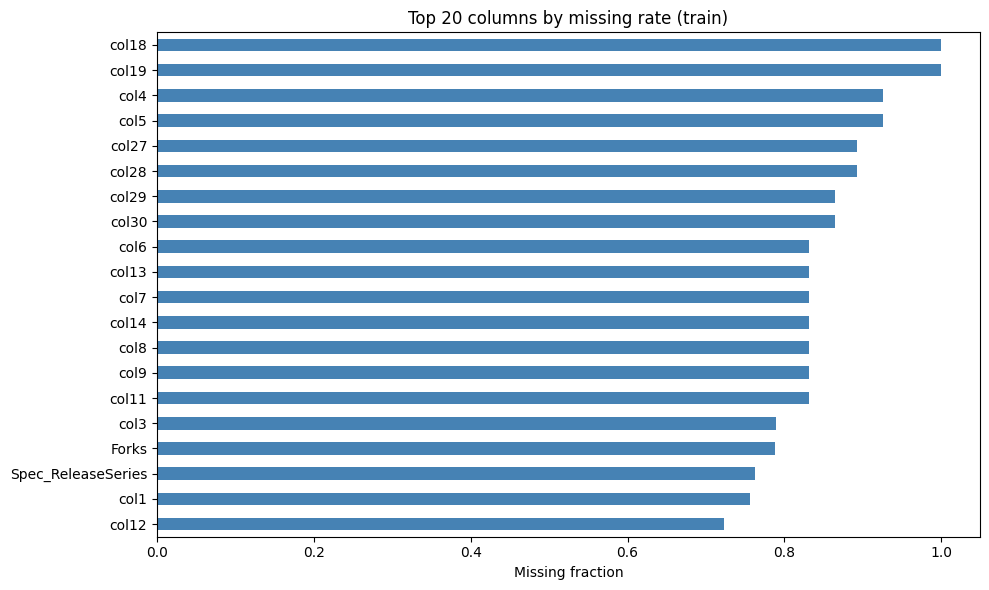

Total columns: 50
Columns with >99.5% missing: 2
Columns with a single unique value: 0


In [5]:
miss = train.isna().mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 6))
miss.head(20).sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 20 columns by missing rate (train)')
ax.set_xlabel('Missing fraction')
plt.tight_layout()
plt.show()

single_val = [c for c in train.columns if train[c].nunique(dropna=False) == 1]
print(f"Total columns: {train.shape[1]}")
print(f"Columns with >99.5% missing: {(miss > 0.995).sum()}")
print(f"Columns with a single unique value: {len(single_val)}")

**Insights and influence on the pipeline.** The dataset has a long tail of nearly empty columns plus columns that never vary. Columns that are more than 99.5% missing with at most two unique values, or that have a single unique value, carry no learnable signal and are dropped in the preprocessing stage - this reduces noise and memory. For the remaining columns, missingness is informative (e.g. an absent specification often means the option was not fitted), so instead of silently imputing, add explicit `_isna` indicator features and only then fill values with train-set medians. That two-step handling (flag, then fill) is applied uniformly in Section 5.

### 4.3 Univariate analysis of key features

Inspect the distributions of the two most important physical numeric columns - `ManufactureYear` and `OperationalHoursMeter` - and the most common levels of the ordered categorical columns `AssetScaleFactor`, `UtilizationTier` and `Spec_ReleaseSeries`.

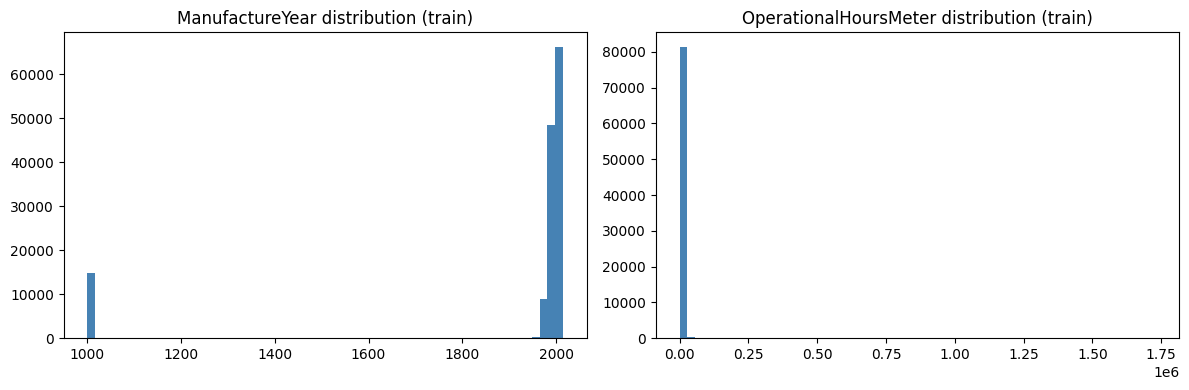

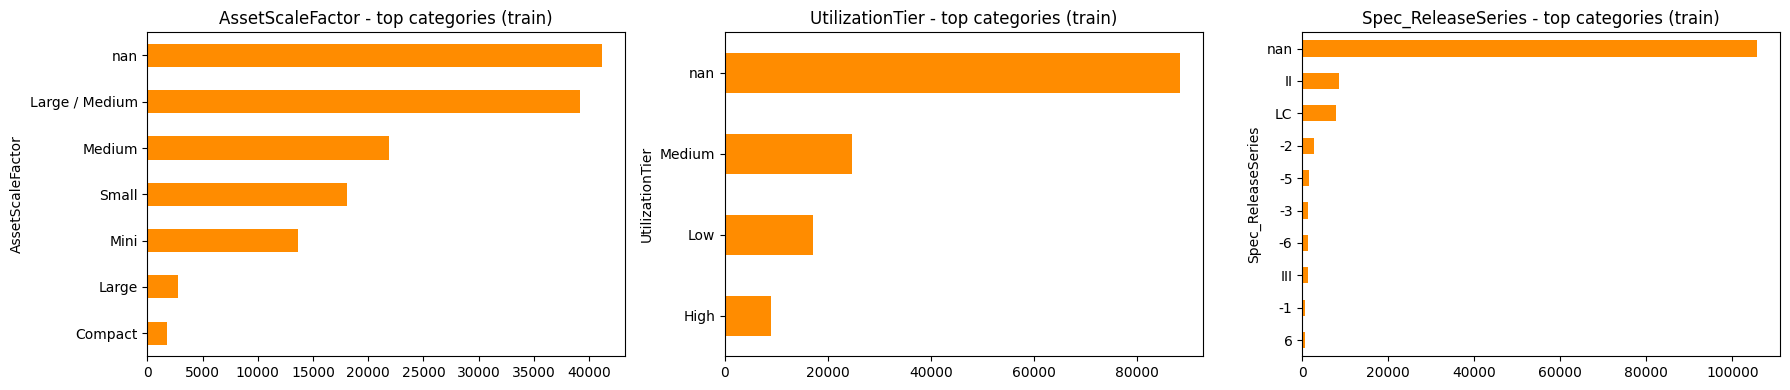

In [6]:
num_view = [c for c in ['ManufactureYear', 'OperationalHoursMeter'] if c in train.columns]
if len(num_view) > 0:
    fig, axes = plt.subplots(1, len(num_view), figsize=(6 * len(num_view), 4))
    if len(num_view) == 1:
        axes = [axes]
    for ax, c in zip(axes, num_view):
        vals = pd.to_numeric(train[c], errors='coerce').dropna()
        ax.hist(vals, bins=60, color='steelblue')
        ax.set_title(f'{c} distribution (train)')
    plt.tight_layout()
    plt.show()

cat_view = [c for c in ['AssetScaleFactor', 'UtilizationTier', 'Spec_ReleaseSeries'] if c in train.columns]
if len(cat_view) > 0:
    fig, axes = plt.subplots(1, len(cat_view), figsize=(6 * len(cat_view), 4))
    if len(cat_view) == 1:
        axes = [axes]
    for ax, c in zip(axes, cat_view):
        train[c].astype(str).value_counts().head(10).sort_values().plot(kind='barh', ax=ax, color='darkorange')
        ax.set_title(f'{c} - top categories (train)')
    plt.tight_layout()
    plt.show()

**Insights and influence on the pipeline.** `ManufactureYear` is concentrated in recent decades with a long old tail, and `OperationalHoursMeter` is right-skewed - the preprocessing stage therefore adds log/square-root transforms for every non-negative skewed numeric column. The categorical columns have a few dominant, clearly ordered levels (small < medium < large; low < medium < high; Roman numeral series), which motivates the explicit ordinal encodings built in the feature-engineering stage so this ordering information is available to the models cheaply.

### 4.4 Bivariate analysis: price vs age and usage

Examine the two textbook depreciation drivers: how the median price moves with `ManufactureYear`, and how price relates to `OperationalHoursMeter`.

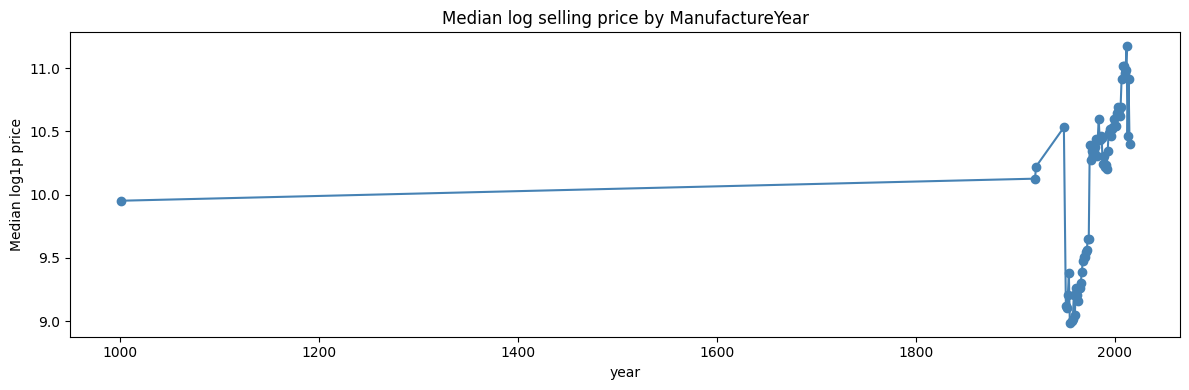

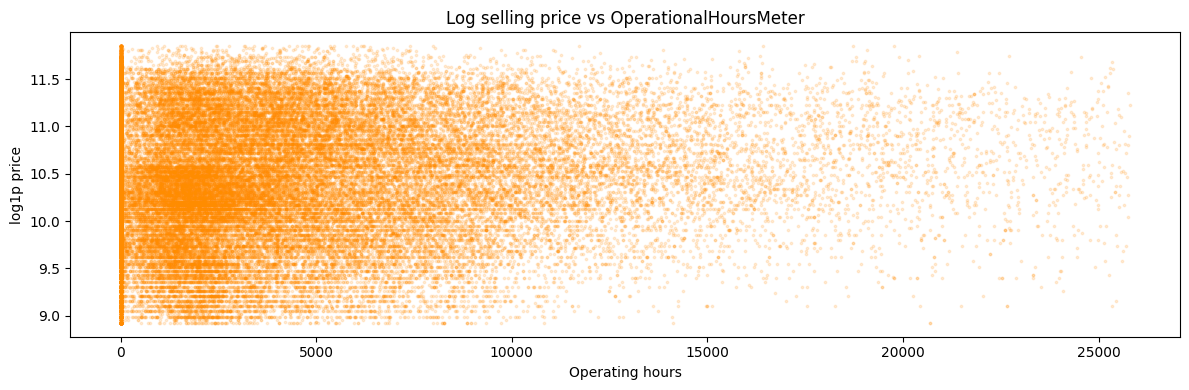

In [7]:
if 'ManufactureYear' in train.columns:
    tmp = pd.DataFrame({'year': pd.to_numeric(train['ManufactureYear'], errors='coerce'), 'log_price': y})
    yr_med = tmp.dropna().groupby('year')['log_price'].median()
    fig, ax = plt.subplots(figsize=(12, 4))
    yr_med.plot(ax=ax, marker='o', color='steelblue')
    ax.set_title('Median log selling price by ManufactureYear')
    ax.set_ylabel('Median log1p price')
    plt.tight_layout()
    plt.show()

if 'OperationalHoursMeter' in train.columns:
    tmp = pd.DataFrame({'hours': pd.to_numeric(train['OperationalHoursMeter'], errors='coerce'), 'log_price': y}).dropna()
    tmp = tmp[tmp['hours'] <= tmp['hours'].quantile(0.99)]
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.scatter(tmp['hours'], tmp['log_price'], s=3, alpha=0.15, color='darkorange')
    ax.set_title('Log selling price vs OperationalHoursMeter')
    ax.set_xlabel('Operating hours')
    ax.set_ylabel('log1p price')
    plt.tight_layout()
    plt.show()

**Insights and influence on the pipeline.** The first plot shows the price goes up and down but mostly rises for newer years. In the second plot, there is a giant line at zero hours and a very flat, messy cloud of dots. Since these relationships are noisy and not in a straight line, three things to make our features: (i) we build AssetAgeAtSale = sale year - manufacture year as a main feature, using square and square-root forms to fit the curves (ii) build a usage feature HoursPerYear because the hours are mostly zero and need to be compared to age (iii) these noisy, non-linear patterns are what gradient-boosted trees model best, which is why we chose them in Section 6.

### 4.5 Correlation of numeric features with the target

As a screening step, compute the absolute Pearson correlation of every raw numeric column with the log target.

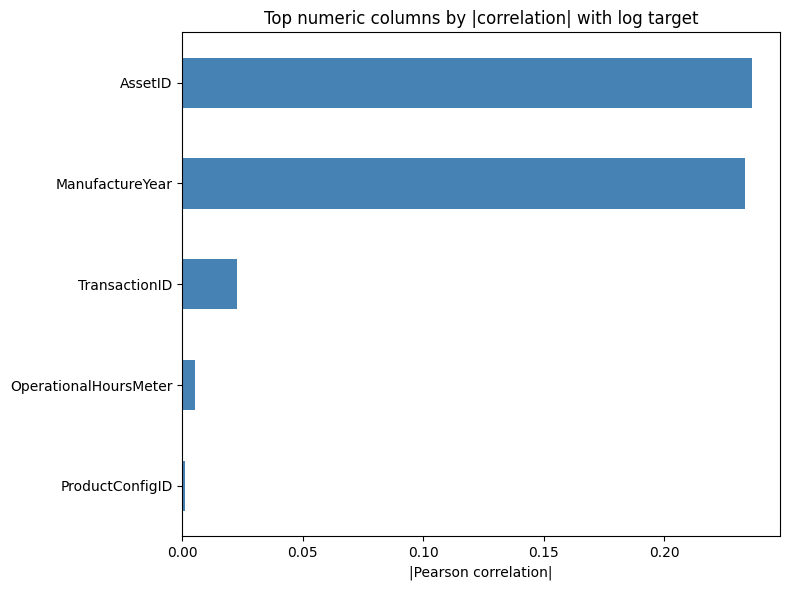

In [8]:
num_train = train.select_dtypes(include=[np.number]).copy()
num_train['log_target'] = y
corr_to_target = num_train.corr(numeric_only=True)['log_target'].drop(labels=['log_target', TARGET], errors='ignore').abs()
corr_to_target = corr_to_target.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
corr_to_target.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top numeric columns by |correlation| with log target')
ax.set_xlabel('|Pearson correlation|')
plt.tight_layout()
plt.show()

**Insights and influence on the pipeline.** If we ignore the ID columns, the plot shows that `ManufactureYear` has a strong correlation with the price. `OperationalHoursMeter` has a correlation that is almost zero. We still use this correlation screening inside our pipeline. After we make all of our new numeric features, the pipeline calculates their correlations with the target on the training data. It then takes the top eight features and automatically pairs them up using division, multiplication, and subtraction to create new features. This helps us find strong combinations of age and usage.

### 4.6 Market price trend over time

Plot the mean selling price per transaction month to check for drift and seasonality in the used-equipment market.

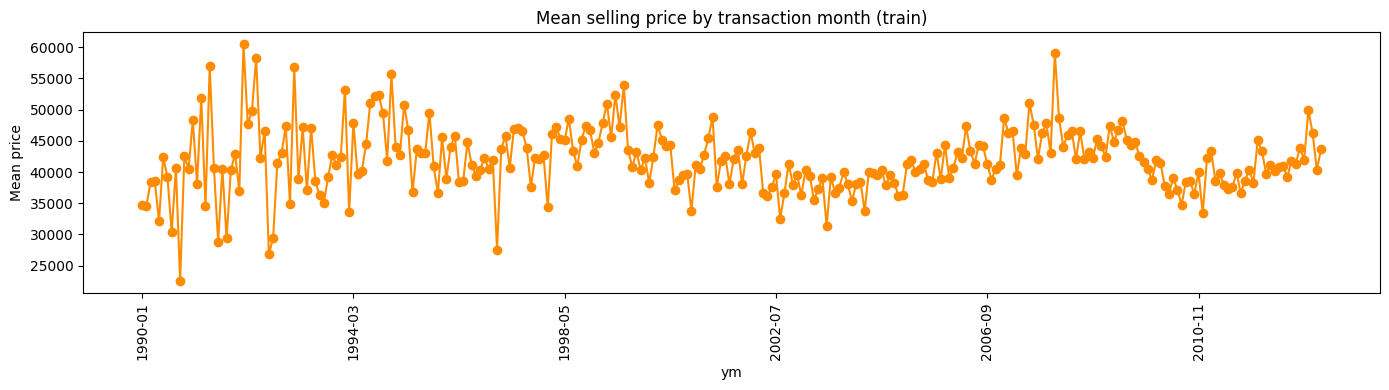

In [9]:
if 'TransactionDate' in train.columns:
    dt = pd.to_datetime(train['TransactionDate'], errors='coerce')
    trend = pd.DataFrame({'ym': dt.dt.strftime('%Y-%m'), 'price': y_raw}).dropna()
    trend = trend.groupby('ym')['price'].mean()
    fig, ax = plt.subplots(figsize=(14, 4))
    trend.plot(ax=ax, marker='o', color='darkorange')
    ax.set_title('Mean selling price by transaction month (train)')
    ax.set_ylabel('Mean price')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

**Insights and influence on the pipeline.** The average transaction price drifts visibly from month to month - the same machine is worth different amounts in different market conditions. This motivates two feature groups: (i) full calendar decomposition of every date column (year, month, quarter, week, day-of-week) so trees can pick the granularity they need, and (ii) a `MarketPriceIndex` feature: the train-only monthly mean log price mapped onto every row, giving each model an explicit market-trend signal. Because the index is computed from training targets only and mapped by calendar month, it carries no information about the test targets.

### 4.7 Resale structure of the data

Finally check how often the exact same `AssetID` is sold more than once, and how much the asset populations of train and test overlap.

In [10]:
if 'AssetID' in train.columns:
    counts = train['AssetID'].value_counts()
    resold = (counts > 1).sum()
    print(f"Unique assets in train: {len(counts)}")
    print(f"Assets sold more than once: {resold} ({100 * resold / len(counts):.1f}%)")
    print(f"Maximum number of sales of a single asset: {counts.max()}")
    if 'AssetID' in test.columns:
        overlap = test['AssetID'].isin(set(train['AssetID'])).mean()
        print(f"Share of test rows whose AssetID also appears in train: {100 * overlap:.1f}%")

Unique assets in train: 120111
Assets sold more than once: 12857 (10.7%)
Maximum number of sales of a single asset: 46
Share of test rows whose AssetID also appears in train: 23.3%


**Insights and influence on the pipeline.** A substantial share of assets is resold, and many test assets already appear in the training data. This is the single most valuable structural finding of the EDA, and it drives two decisions: (i) a **prior-sale feature** - the most recent earlier sale price of the same asset, and how long ago it happened - is engineered in Section 5 (built strictly in date order so it only uses information that genuinely exists at prediction time); (ii) `AssetID` and other ID-like columns are **target-encoded despite their high cardinality**, because a per-machine identifier is highly predictive when machines reappear. The resale pattern also confirms that transaction-date ordering matters and that random shuffling without care could leak information, which the date-ordered construction explicitly avoids.

## 5. Preprocessing and feature engineering

This stage follows four design principles:

1. **Reusable custom functions.** All parsing and encoding logic lives in named helper functions (`norm_text`, `parse_horsepower`, `target_encode_oof`, ...) that are reused everywhere, instead of scattered one-off edits.
2. **Identical transformations for train and test.** Train (without the target) and test are concatenated into one frame `full`. Every cleaning, parsing and feature-engineering step runs on `full`, so train and test can never drift apart and no code is duplicated.
3. **Strict leakage control.** Any statistic that uses target values or training information - target encodings, group aggregates, count features, median fills, the scaler - is computed on the training slice `full.iloc[:n_train]` only and then *mapped* onto all rows. Test targets are never touched, and no train statistic ever sees test targets.
4. **Explicit missing-value strategy.** Missingness is first captured as indicator features, then numeric gaps are filled with train-set medians.

The steps below follow the EDA findings point by point.

### 5.1 Combining train and test, dropping useless columns

As established in EDA 4.2, columns that are almost entirely empty (more than 99.5% missing with at most two unique values) or completely constant carry no signal. Dropping them before engineering features saves memory and prevents downstream steps from wasting capacity on noise. The check runs on the combined frame so a column is dropped for train and test together.

In [11]:
train_base = train.drop(columns=[TARGET]).copy()
full = pd.concat([train_base, test], axis=0, ignore_index=True)

drop_cols = []
for c in full.columns:
    if c == ID_COL:
        continue
    miss = full[c].isna().mean()
    nuniq = full[c].nunique(dropna=False)
    if miss > 0.995 and nuniq <= 2:
        drop_cols.append(c)
    elif nuniq == 1:
        drop_cols.append(c)

full.drop(columns=drop_cols, inplace=True, errors='ignore')

### 5.2 Reusable helper functions

These functions encode all the domain knowledge needed to turn messy text into numbers:

- `norm_text` standardizes categorical text (trim, lowercase, collapse whitespace) and converts placeholder strings such as `none or unspecified` into genuine missing values, so that "unknown" is treated consistently everywhere.
- `extract_number` / `extract_year_text` pull the first number or plausible year out of mixed strings, stripping thousands separators and quotes first.
- `parse_horsepower`: values stated in kW are converted to HP (x1.341) so all power values share one unit.
- `parse_tire_size` extracts the leading numeric size from tire strings.
- `parse_length_inches` understands the imperial `feet'inches"` format (e.g. `15' 9"` becomes 189 inches) before falling back to a plain number.
- `rmsle_log` evaluates predictions that live in log space by converting back with `expm1` and computing the competition metric in original price units - every score reported in this notebook is a true RMSLE on prices.

In [12]:
def norm_text(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    s = re.sub(r'\s+', ' ', s)
    if s in {'', 'nan', 'none', 'null', 'na', 'n/a', 'unknown', 'missing', 'unspc',
             'none or unspecified', 'unspecified'}:
        return np.nan
    return s

def extract_number(s):
    if pd.isna(s):
        return np.nan
    s = str(s).replace(',', '').replace("'", "").replace('"', '')
    m = re.search(r'[-+]?\d+\.?\d*', s)
    return float(m.group()) if m else np.nan

def extract_year_text(s):
    if pd.isna(s):
        return np.nan
    m = re.search(r'(19|20)\d{2}', str(s))
    if m:
        y = int(m.group())
        if 1950 <= y <= 2030:
            return float(y)
    return np.nan

def parse_horsepower(s):
    """Parse HP or kW from col9."""
    if pd.isna(s):
        return np.nan
    s = str(s).lower().replace(',', '')
    m = re.search(r'(\d+\.?\d*)\s*(?:hp|horsepower|kw|kilowatt)?', s)
    if m:
        val = float(m.group(1))
        if 'kw' in s or 'kilowatt' in s:
            val *= 1.341  # kW to HP
        return val
    return np.nan

def parse_tire_size(s):
    """Parse tire size from col15."""
    if pd.isna(s):
        return np.nan
    s = str(s).replace(',', '').replace('"', '').replace("'", '')
    m = re.search(r'(\d+\.?\d*)', s)
    return float(m.group(1)) if m else np.nan

def parse_length_inches(s):
    """Parse boom length from col22 handling feet'inches"."""
    if pd.isna(s):
        return np.nan
    s = str(s).replace(',', '')
    # 15' 9" or 15'9"
    m = re.search(r"(\d+)\s*['′]\s*(\d+)\s*[\"″]", s)
    if m:
        return float(m.group(1)) * 12 + float(m.group(2))
    # Just inches or numeric
    m = re.search(r'(\d+\.?\d*)', s)
    return float(m.group(1)) if m else np.nan

def rmsle_log(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    y_pred = np.clip(y_pred, 1e-6, None)
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

### 5.3 Date processing

Motivated by the market drift found in EDA 4.6, every column whose name or content looks date-like is parsed with `pd.to_datetime`. A column is accepted as a date only if at least 20% of its values parse successfully - this threshold guards against numeric codes that coincidentally parse as dates. Each accepted date is decomposed into year, month, day, day-of-week, quarter, week-of-year, age relative to `REF_YEAR`, days since 2000, and a weekend flag. Multiple granularities are provided deliberately: tree models can then choose the time scale (seasonal month effects vs long-run trend) that best explains price movements.

In [13]:
date_cols_found = []
for col in full.columns:
    if col == ID_COL:
        continue
    if any(k in col.lower() for k in ['date', 'time', 'month', 'day', 'year']):
        try:
            dt = pd.to_datetime(full[col], errors='coerce')
            if dt.notna().mean() > 0.2:
                date_cols_found.append(col)
                full[col + '_year'] = dt.dt.year.astype('float32')
                full[col + '_month'] = dt.dt.month.astype('float32')
                full[col + '_day'] = dt.dt.day.astype('float32')
                full[col + '_dow'] = dt.dt.dayofweek.astype('float32')
                full[col + '_quarter'] = dt.dt.quarter.astype('float32')
                full[col + '_weekofyear'] = dt.dt.isocalendar().week.astype('float32')
                full[col + '_age'] = (REF_YEAR - dt.dt.year).astype('float32')
                full[col + '_days_since_2000'] = ((dt - pd.Timestamp('2000-01-01')).dt.days).astype('float32')
                full[col + '_is_weekend'] = (dt.dt.dayofweek >= 5).astype(np.int8)
        except:
            pass

print(f"Date columns processed: {len(date_cols_found)}")

Date columns processed: 2


### 5.4 Domain features: depreciation, utilization, model identity

These features implement the depreciation story that EDA 4.3 and 4.4 revealed:

1. **`AssetAgeAtSale`** = transaction year − manufacture year (clipped at 0), plus squared and square-root versions to capture the non-linear depreciation curve.
2. **Utilization intensity** - `HoursPerYear` separates gently used from heavily used machines of the same age; the `Age_x_Hours` interaction lets the model price wear-and-tear jointly.
3. **`ModelCode`** - a composite key of base class, subclass and release series that identifies the exact product more precisely than any single column.
4. **`Spec_BaseClass` as a number** - the model series number encodes the machine's size class, so it is parsed numerically (with a log version).
5. **Roman numeral release series** - `i` to `x` mapped to generation numbers 1–10, turning an ordered label into a usable numeric.
6. **`SizeMidpoint`** - the midpoint of size-range strings such as `120 to 150 hp` in `FunctionalClassification`.
7. **Ordinal encodings** - `AssetScaleFactor` (small to extra large) and `UtilizationTier` (low to high) mapped to ordered integers, exactly as their EDA distributions suggested.

In [14]:
# 1. Asset age at sale
if 'ManufactureYear' in full.columns and 'TransactionDate_year' in full.columns:
    full['AssetAgeAtSale'] = (full['TransactionDate_year'] - full['ManufactureYear']).astype('float32')
    full['AssetAgeAtSale'] = full['AssetAgeAtSale'].clip(lower=0)
    full['AssetAgeAtSale_sq'] = (full['AssetAgeAtSale'] ** 2).astype('float32')
    full['AssetAgeAtSale_sqrt'] = np.sqrt(full['AssetAgeAtSale'] + 1).astype('float32')

# 2. Utilization intensity
if 'OperationalHoursMeter' in full.columns and 'AssetAgeAtSale' in full.columns:
    full['HoursPerYear'] = (full['OperationalHoursMeter'] / (full['AssetAgeAtSale'] + 1)).astype('float32')
    full['HoursPerYear_log'] = np.log1p(full['HoursPerYear'].clip(lower=0)).astype('float32')
    full['Age_x_Hours'] = (full['AssetAgeAtSale'] * np.log1p(full['OperationalHoursMeter'].fillna(0))).astype('float32')

# 3. Model code combination
model_parts = []
for c in ['Spec_BaseClass', 'Spec_SubClass', 'Spec_ReleaseSeries']:
    if c in full.columns:
        model_parts.append(full[c].astype(str).fillna('NA'))
if len(model_parts) > 0:
    full['ModelCode'] = model_parts[0].str.cat(model_parts[1:], sep='_')
    full['ModelCode'] = full['ModelCode'].str.replace(r'_+', '_', regex=True).str.strip('_').str.lower()
    full['ModelCode'] = full['ModelCode'].replace({'': '__missing__', 'nan': '__missing__'})

# 4. Parse Spec_BaseClass as numeric (model series number = size class)
if 'Spec_BaseClass' in full.columns:
    sbc = pd.to_numeric(full['Spec_BaseClass'], errors='coerce')
    if sbc.notna().mean() > 0.3:
        full['Spec_BaseClass_num'] = sbc.astype('float32')
        full['Spec_BaseClass_log'] = np.log1p(sbc).astype('float32')

# 5. Parse Spec_ReleaseSeries Roman numerals to numeric
roman_map = {'i': 1, 'ii': 2, 'iii': 3, 'iv': 4, 'v': 5, 'vi': 6, 'vii': 7, 'viii': 8, 'ix': 9, 'x': 10}
if 'Spec_ReleaseSeries' in full.columns:
    srs = full['Spec_ReleaseSeries'].astype(str).str.lower().str.strip()
    full['Spec_ReleaseSeries_num'] = srs.map(roman_map).astype('float32')

# 6. Extract size midpoint from FunctionalClassification
def extract_size_midpoint(s):
    if pd.isna(s):
        return np.nan
    m = re.search(r'(\d+\.?\d*)\s*to\s*(\d+\.?\d*)', str(s))
    if m:
        return (float(m.group(1)) + float(m.group(2))) / 2.0
    m = re.search(r'(\d+\.?\d*)', str(s))
    if m:
        return float(m.group(1))
    return np.nan

if 'FunctionalClassification' in full.columns:
    full['SizeMidpoint'] = full['FunctionalClassification'].map(extract_size_midpoint).astype('float32')

# 7. Ordinal encodings
scale_map = {'small': 1, 'medium': 2, 'large / medium': 3, 'large': 4, 'extra large': 5}
if 'AssetScaleFactor' in full.columns:
    full['AssetScaleFactor_ord'] = full['AssetScaleFactor'].astype(str).str.lower().map(scale_map).fillna(2).astype('float32')

util_map = {'low': 1, 'medium': 2, 'high': 3}
if 'UtilizationTier' in full.columns:
    full['UtilizationTier_ord'] = full['UtilizationTier'].astype(str).str.lower().map(util_map).fillna(2).astype('float32')

### 5.5 Physical specifications, market trend, counts, equipment type

- **Physical spec parsing.** Horsepower, tire size and boom length are the classic physical price drivers for heavy machinery; they are parsed from raw text columns into clean numerics (with a log horsepower).
- **`MarketPriceIndex`.** The monthly mean log price from EDA 4.6, computed on the training rows only and mapped by calendar month onto every row; unseen months fall back to the train median. This gives each model the market-level trend explicitly.
- **Count features.** How often an asset, configuration, vendor or model code appears in the training data - a proxy for popularity and market liquidity. 
- **`EquipmentType`.** The prefix of `FunctionalClassification` before the ` - ` separator, a cleaner machine-type label than the full string.

In [15]:
# 8. Physical spec parsing (critical price drivers)
if 'col9' in full.columns:
    full['Horsepower'] = full['col9'].map(parse_horsepower).astype('float32')
    full['Horsepower_log'] = np.log1p(full['Horsepower'].fillna(0)).astype('float32')

if 'col15' in full.columns:
    full['TireSize'] = full['col15'].map(parse_tire_size).astype('float32')

if 'col22' in full.columns:
    full['BoomLength_inches'] = full['col22'].map(parse_length_inches).astype('float32')

# 9. Market price trend by year-month
if 'TransactionDate' in train.columns:
    train_temp = train.copy()
    train_temp['TransactionDate_dt'] = pd.to_datetime(train_temp['TransactionDate'], errors='coerce')
    train_temp['YearMonth'] = train_temp['TransactionDate_dt'].dt.strftime('%Y-%m')
    ym_price = train_temp.groupby('YearMonth')[TARGET].mean()
    ym_price_log = np.log1p(ym_price)

    full['TransactionDate_dt'] = pd.to_datetime(full['TransactionDate'], errors='coerce')
    full['YearMonth'] = full['TransactionDate_dt'].dt.strftime('%Y-%m')
    full['MarketPriceIndex'] = full['YearMonth'].map(ym_price_log).astype('float32')
    full['MarketPriceIndex'] = full['MarketPriceIndex'].fillna(ym_price_log.median())

# 10. Non-leaky count features (how often an asset/config appears)
for col in ['AssetID', 'ProductConfigID', 'VendorPartnerID', 'ModelCode']:
    if col in full.columns:
        cnt = full.iloc[:n_train][col].value_counts()
        full[f'{col}_count'] = full[col].map(cnt).fillna(0).astype('float32')

# 11. Equipment type from FunctionalClassification
if 'FunctionalClassification' in full.columns:
    full['EquipmentType'] = full['FunctionalClassification'].astype(str).str.split(' - ').str[0].str.strip().str.lower()
    full['EquipmentType'] = full['EquipmentType'].fillna('unknown')

### 5.6 Prior-sale price of the same asset

This is the feature motivated by EDA 4.7: heavy equipment is frequently resold, so the most recent **earlier** sale price of the exact same `AssetID` - and how long ago it happened - reflects that specific machine's market value close in time.

**Why this is not leakage.** For any given row, the construction only ever looks at *earlier* transactions of the same asset, i.e. information that genuinely exists at prediction time. Three implementation details enforce this: (i) the combined frame is sorted by asset and date before any shifting; (ii) within each asset, `shift(1).ffill()` propagates only the most recent *previous* known price and its date; (iii) test rows carry `NaN` targets, so a test row can receive a prior price from an earlier *training* sale but never from another test row's unknown target. `HasPrevSale` flags rows with a known prior sale, and missing values are filled with the explicit sentinel −1 so models can distinguish "no prior sale" from a genuine price.

In [16]:
if 'AssetID' in full.columns and 'TransactionDate_dt' in full.columns:
    target_known = pd.Series(np.nan, index=full.index, dtype='float64')
    target_known.iloc[:n_train] = y_raw  # raw TargetValue, train rows only, test rows stay NaN

    order = pd.DataFrame({
        'AssetID': full['AssetID'].values,
        'dt': full['TransactionDate_dt'].values,
        'target_known': target_known.values,
        'orig_idx': np.arange(len(full))
    }).sort_values(['AssetID', 'dt'], kind='mergesort')

    order['dt_if_known'] = order['dt'].where(order['target_known'].notna())

    grp = order.groupby('AssetID')
    order['prev_price'] = grp['target_known'].transform(lambda s: s.shift(1).ffill())
    order['prev_dt'] = grp['dt_if_known'].transform(lambda s: s.shift(1).ffill())

    order = order.sort_values('orig_idx')

    full['PrevSalePrice'] = order['prev_price'].astype('float64').values
    days_diff = (order['dt'] - order['prev_dt']).dt.days
    full['DaysSincePrevSale'] = days_diff.astype('float64').values

    full['HasPrevSale'] = full['PrevSalePrice'].notna().astype(np.int8)
    full['PrevSalePrice'] = full['PrevSalePrice'].fillna(-1).astype('float32')
    full['DaysSincePrevSale'] = full['DaysSincePrevSale'].fillna(-1).astype('float32')

    print(f"Assets with a known prior sale: {int(full['HasPrevSale'].sum())} / {len(full)}")

Assets with a known prior sale: 20697 / 153701


### 5.7 Numeric processing

Three things happen here:

1. **Missing-value indicators.** Every numeric column gets an `_isna` flag, preserving the "absent specification" signal identified in EDA 4.2.
2. **Skew-robust transforms.** Every non-negative numeric column with range beyond 1 gets a `log1p` copy, and every non-negative column gets a `sqrt` copy - cheap variance stabilizers that the EDA distributions in 4.3 showed these columns need.
3. **Correlation-guided interactions.** Correlations with the log target are recomputed on the **training rows only** , and the eight strongest numerics receive pairwise division, multiplication and subtraction features. Ratios in particular act as price-per-unit proxies; products approximate joint capacity effects. Capping at 20 iterations keeps the feature count under control.

In [17]:
num_cols = [c for c in full.columns if c != ID_COL and pd.api.types.is_numeric_dtype(full[c])]
print(f"Base numeric columns: {len(num_cols)}")

for col in num_cols:
    full[col + '_isna'] = full[col].isna().astype(np.int8)
    ser = pd.to_numeric(full[col], errors='coerce')
    if ser.notna().sum() > 0 and ser.min(skipna=True) >= 0 and ser.max(skipna=True) > 1:
        full[col + '_log1p'] = np.log1p(ser).astype('float32')
    if ser.notna().sum() > 0 and ser.min(skipna=True) >= 0:
        full[col + '_sqrt'] = np.sqrt(ser).astype('float32')

num_cols = [c for c in full.columns if c != ID_COL and pd.api.types.is_numeric_dtype(full[c])]

tmp = full.iloc[:n_train][num_cols].copy()
tmp['y'] = y
corrs = []
for c in num_cols:
    try:
        mask = tmp[c].notna()
        if mask.sum() > 200:
            corr = np.abs(np.corrcoef(tmp.loc[mask, c], tmp.loc[mask, 'y'])[0,1])
            if not np.isnan(corr):
                corrs.append((corr, c))
    except:
        pass

corrs.sort(reverse=True)
print(f"Top 10 numeric correlations: {corrs[:10]}")

top_num = [c for _, c in corrs[:8]]
cnt = 0
for i in range(len(top_num)):
    for j in range(i+1, len(top_num)):
        if cnt >= 20:
            break
        c1, c2 = top_num[i], top_num[j]
        full[f'{c1}_div_{c2}'] = (full[c1] / (full[c2] + 1e-6)).astype('float32')
        full[f'{c1}_mul_{c2}'] = (full[c1] * full[c2]).astype('float32')
        full[f'{c1}_sub_{c2}'] = (full[c1] - full[c2]).astype('float32')
        cnt += 3

Base numeric columns: 46
Top 10 numeric correlations: [(np.float64(0.4082934512044638), 'SizeMidpoint_log1p'), (np.float64(0.34936825960861256), 'AssetAgeAtSale_sq_log1p'), (np.float64(0.34316262485518784), 'AssetAgeAtSale_log1p'), (np.float64(0.3412580137215503), 'SizeMidpoint_sqrt'), (np.float64(0.33683800904109634), 'AssetAgeAtSale_sqrt_log1p'), (np.float64(0.3167165809471178), 'ModelCode_count_sqrt'), (np.float64(0.3024763568855734), 'AssetAgeAtSale_sqrt_sqrt'), (np.float64(0.30173507547026013), 'ModelCode_count_log1p'), (np.float64(0.290365307272172), 'ModelCode_count'), (np.float64(0.2694669763036345), 'ProductConfigID_count_sqrt')]


### 5.8 Categorical processing: normalization and string-derived features

Every remaining object column is first cleaned with `norm_text` (Section 5.2) and filled with the explicit level `__missing__`. Columns that are actually dates are skipped - they were already handled in 5.3. From each cleaned categorical, derive:

- an `_isna` flag plus string-structure numerics (`_len`, `_words`, `_digits`, `_has_dash`, `_has_slash`) - the shape of a code string often identifies the coding scheme;
- `_num` and `_num_log1p`: any number embedded in the string (kept when at least 2% of rows have one);
- `_yr` and `_age_yr`: any year embedded in the string (e.g. a model-year hidden in a description);
- `_first` / `_last` token categoricals: composite codes like `cat-336-gc` often put the brand or class in a consistent position, so the first and last tokens become categoricals of their own.

Finally, rare levels seen fewer than 3 times are collapsed into `__rare__`. Rare levels produce unstable statistics in every downstream encoding, so grouping them is a simple regularization that improves generalization.

In [18]:
obj_cols = [c for c in full.columns if c not in num_cols + [ID_COL] and not pd.api.types.is_numeric_dtype(full[c])]
print(f"Object columns: {len(obj_cols)}")

cat_cols = []
orig_cat = []

for col in obj_cols:
    s = full[col].map(norm_text)
    sample = s.dropna().astype(str).head(300)
    dr = 0.0
    if len(sample) > 0:
        try:
            dr = pd.to_datetime(sample, errors='coerce').notna().mean()
        except:
            dr = 0.0

    is_date_name = any(k in col.lower() for k in ['date', 'time', 'month', 'day', 'year', 'timestamp'])
    if (is_date_name and dr > 0.2) or (dr > 0.95):
        continue

    full[col] = s.fillna('__missing__')
    orig_cat.append(col)
    cat_cols.append(col)
    filled = full[col].astype(str)

    full[col + '_isna'] = (filled == '__missing__').astype(np.int8)
    full[col + '_len'] = filled.str.len().astype(np.int16)
    full[col + '_words'] = filled.str.count(r'\S+').astype(np.int16)
    full[col + '_digits'] = filled.str.count(r'\d').astype(np.int16)
    full[col + '_has_dash'] = filled.str.contains('-').astype(np.int8)
    full[col + '_has_slash'] = filled.str.contains('/').astype(np.int8)

    num_feat = s.map(extract_number)
    if num_feat.notna().mean() >= 0.02:
        full[col + '_num'] = num_feat.astype('float32')
        if num_feat.notna().sum() > 0 and num_feat.min(skipna=True) >= 0:
            full[col + '_num_log1p'] = np.log1p(num_feat).astype('float32')

    yr = s.map(extract_year_text)
    if yr.notna().mean() >= 0.005:
        full[col + '_yr'] = yr.astype('float32')
        full[col + '_age_yr'] = (REF_YEAR - yr).astype('float32')

    parts = filled.str.split(r'[\s/_\-|,.;:()]+')
    first_tok = parts.str[0].fillna('__missing__')
    last_tok = parts.str[-1].fillna('__missing__')

    if first_tok.nunique(dropna=False) > 1:
        full[col + '_first'] = first_tok
        cat_cols.append(col + '_first')
    if last_tok.nunique(dropna=False) > 1 and last_tok.nunique() != first_tok.nunique():
        full[col + '_last'] = last_tok
        cat_cols.append(col + '_last')

for col in cat_cols:
    if col not in full.columns:
        continue
    vc = full[col].value_counts(dropna=False)
    rare = vc[vc < 3].index
    full[col] = full[col].where(~full[col].isin(rare), '__rare__').fillna('__missing__')

Object columns: 48


### 5.9 Categorical crosses, frequencies, and group aggregates

- **Crosses.** Up to eight pairwise combinations of mid-cardinality categoricals (e.g. equipment type crossed with region) are new `col1|col2` columns. Crosses expose interaction effects directly, so the trees do not have to spend many splits rediscovering them. Rare combinations are again collapsed to `__rare__`.
- **Count and frequency features.** Every categorical gets `_cnt` and `_freq` numerics - how common each level is - a safe, target-free encoding.
- **Group aggregates.** For the five highest-signal categoricals, compute the mean, standard deviation, median, minimum and maximum of the top numeric features *per category level* and map them back onto each row. This captures statements like "this model series typically sells in this price-relevant range for its hours". All aggregates are computed on the **training slice only** (`full.iloc[:n_train]`) and then mapped onto both train and test - the mapping itself is just a lookup, so the test rows contribute nothing to the statistics.

In [19]:
cross_cands = []
for c in orig_cat:
    if c not in full.columns:
        continue
    nun = full[c].nunique(dropna=True)
    if 2 <= nun <= 600:
        cross_cands.append((nun, c))
cross_cands = [c for _, c in sorted(cross_cands, reverse=True)[:8]]

cross_cols = []
for i in range(len(cross_cands)):
    for j in range(i+1, len(cross_cands)):
        if len(cross_cols) >= 8:
            break
        c1, c2 = cross_cands[i], cross_cands[j]
        nc = f'{c1}__{c2}'
        full[nc] = full[c1].astype(str) + '|' + full[c2].astype(str)
        vc = full[nc].value_counts(dropna=False)
        rare = vc[vc < 3].index
        full[nc] = full[nc].where(~full[nc].isin(rare), '__rare__').fillna('__missing__')
        cross_cols.append(nc)
    if len(cross_cols) >= 8:
        break

cat_cols = cat_cols + cross_cols

for col in cat_cols:
    if col not in full.columns:
        continue
    cnts = full[col].value_counts(dropna=False)
    full[col + '_cnt'] = full[col].map(cnts).astype(np.float32)
    full[col + '_freq'] = (full[col].map(cnts) / len(full)).astype(np.float32)

group_candidates = [c for c in orig_cat if c in full.columns and 5 <= full[c].nunique(dropna=True) <= 2500]
group_candidates = sorted(group_candidates, key=lambda c: full[c].nunique(dropna=True), reverse=True)[:5]

num_for_group = [c for c in full.columns if pd.api.types.is_numeric_dtype(full[c]) and c != ID_COL
                 and not c.endswith('_isna') and not c.endswith('_cnt') and not c.endswith('_freq')
                 and not c.startswith('row_')][:10]

for gcol in group_candidates:
    for ncol in num_for_group:
        mapper_mean = full.iloc[:n_train].groupby(gcol)[ncol].mean()
        mapper_std = full.iloc[:n_train].groupby(gcol)[ncol].std()
        mapper_med = full.iloc[:n_train].groupby(gcol)[ncol].median()
        mapper_min = full.iloc[:n_train].groupby(gcol)[ncol].min()
        mapper_max = full.iloc[:n_train].groupby(gcol)[ncol].max()
        full[f'{gcol}_mean_{ncol}'] = full[gcol].map(mapper_mean).astype('float32')
        full[f'{gcol}_std_{ncol}'] = full[gcol].map(mapper_std).astype('float32')
        full[f'{gcol}_med_{ncol}'] = full[gcol].map(mapper_med).astype('float32')
        full[f'{gcol}_min_{ncol}'] = full[gcol].map(mapper_min).astype('float32')
        full[f'{gcol}_max_{ncol}'] = full[gcol].map(mapper_max).astype('float32')

### 5.10 Feature hashing for high-cardinality categoricals

The fifteen highest-cardinality categoricals (thousands of levels each, such as `AssetID`) cannot be one-hot encoded. Instead, each row's `column=value` tokens are projected by scikit-learn's `FeatureHasher` into a fixed 256-dimensional sparse indicator matrix. Collisions are possible but harmless at this scale, and `alternate_sign=False` keeps entries non-negative. This sparse block will be stacked onto the dense features for the `xgb_sparse` model - a cheap way to give one model direct access to raw categorical identity.

In [20]:
hash_cols = []
for c in orig_cat:
    if c not in full.columns:
        continue
    nun = full[c].nunique(dropna=True)
    hash_cols.append((nun, c))
hash_cols = [c for _, c in sorted(hash_cols, reverse=True)[:15]]

def build_tokens(df, cols):
    arr = df[cols].astype(str).values
    tokens = []
    for row in arr:
        toks = []
        for j in range(len(cols)):
            v = row[j]
            if v != '__missing__':
                toks.append(f'{cols[j]}={v}')
        tokens.append(toks)
    return tokens

hasher = FeatureHasher(n_features=256, input_type='string', alternate_sign=False)
hash_matrix = hasher.transform(build_tokens(full, hash_cols))
hash_train = hash_matrix[:n_train]
hash_test = hash_matrix[n_train:]

### 5.11 Cross-validation design: stratified folds

The combined frame is split back into `train_feat` and `test_feat`. For cross-validation use **stratified** 5-fold splitting: the log target is discretized into quantile bins and `StratifiedKFold` ensures every fold has the same price distribution. With skewed targets, plain random folds can accidentally concentrate expensive machines in one fold and produce misleading validation scores; stratification removes that risk. The same fixed fold list is used for every model and for target encoding, so all out-of-fold predictions are perfectly aligned - a prerequisite for honest model comparison and stacking later.

In [21]:
train_feat = full.iloc[:n_train].copy()
test_feat = full.iloc[n_train:].copy()

n_bins = min(15, max(5, n_train // 500))
y_bins = pd.qcut(pd.Series(y), q=n_bins, labels=False, duplicates='drop')
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
folds = list(skf.split(train_feat, y_bins))

### 5.12 Target encoding of categoricals (out-of-fold, smoothed)

Target encoding replaces each categorical level with the mean log target of that level - one of the most powerful encodings for tree models on high-cardinality data. Done naively it leaks the target into the features, so two safeguards are applied:

1. **Out-of-fold (OOF) encoding for train rows.** Each fold is encoded using statistics computed on the other four folds only, so no row's encoding ever includes its own target. Test rows are encoded with statistics from the full training data.
2. **Smoothing toward the global prior.** The encoding is `enc = (count * level_mean + smoothing * global_mean) / (count + smoothing)`. Levels with many observations keep their own mean; rare levels (including ones seen once) are shrunk toward the global average, which makes even extremely high-cardinality columns safe to encode.

The top 30 categorical candidates are encoded. A general cardinality cap of 3000 is applied, but the strongest ID-like signals (`ModelCode`, `ProductConfigID`, `AssetID`, `VendorPartnerID`, `RegionCode`, `EquipmentType`, `Spec_FullDescriptor`) are **force-included beyond the cap** - the smoothing above is precisely what makes high cardinality safe, and EDA 4.7 showed these identifiers reappear across train and test. The five strongest candidates are encoded with three smoothing strengths (10, 30, 50) so the models can choose; the rest use a default of 20.

In [22]:
def target_encode_oof(train_series, test_series, y, folds, smoothing):
    prior = float(np.mean(y))
    oof = np.zeros(len(train_series), dtype=np.float32)
    train_series = train_series.astype(str)
    test_series = test_series.astype(str)
    for tr_idx, val_idx in folds:
        stats = pd.DataFrame({'x': train_series.iloc[tr_idx].values, 'y': y[tr_idx]}).groupby('x')['y'].agg(['mean', 'count'])
        enc = (stats['count'] * stats['mean'] + smoothing * prior) / (stats['count'] + smoothing)
        oof[val_idx] = train_series.iloc[val_idx].map(enc).fillna(prior).values.astype(np.float32)
    stats = pd.DataFrame({'x': train_series.values, 'y': y}).groupby('x')['y'].agg(['mean', 'count'])
    enc = (stats['count'] * stats['mean'] + smoothing * prior) / (stats['count'] + smoothing)
    test_enc = test_series.map(enc).fillna(prior).values.astype(np.float32)
    return oof, test_enc

te_candidates = []
for c in cat_cols:
    if c not in train_feat.columns:
        continue
    nun = train_feat[c].nunique(dropna=True)
    if 2 <= nun <= 3000:
        te_candidates.append((nun, c))

force_cols = ['ModelCode', 'ProductConfigID', 'AssetID', 'VendorPartnerID',
              'RegionCode', 'EquipmentType', 'Spec_FullDescriptor']
print("Cardinality check on forced ID-like columns (previous cap was <=3000):")
for fc in force_cols:
    if fc in train_feat.columns:
        print(f"  {fc}: nunique={train_feat[fc].nunique(dropna=True)}, "
              f"already_included={fc in [x for _, x in te_candidates]}")
for fc in force_cols:
    if fc in train_feat.columns and fc not in [x for _, x in te_candidates]:
        nun = train_feat[fc].nunique(dropna=True)
        if nun >= 2:
            te_candidates.append((nun, fc))

te_candidates = [c for _, c in sorted(te_candidates, reverse=True)[:30]]

for col in te_candidates:
    smooths = [10, 30, 50] if col in set(te_candidates[:5]) else [20]
    for sm in smooths:
        tr_te, te_te = target_encode_oof(train_feat[col], test_feat[col], y, folds, sm)
        train_feat[f'{col}_te_{sm}'] = tr_te
        test_feat[f'{col}_te_{sm}'] = te_te

Cardinality check on forced ID-like columns (previous cap was <=3000):
  ModelCode: nunique=2034, already_included=True
  ProductConfigID: nunique=3594, already_included=False
  AssetID: nunique=120111, already_included=False
  VendorPartnerID: nunique=31, already_included=True
  RegionCode: nunique=53, already_included=True
  EquipmentType: nunique=6, already_included=True
  Spec_FullDescriptor: nunique=2393, already_included=True


### 5.13 Integer codes and dropping raw strings

Every categorical is also converted to an integer code via joint factorization of train and test (`sort=True` makes the mapping deterministic). These `_code` columns serve two purposes: LightGBM consumes them through its native categorical-split mechanism (`categorical_feature`), and XGBoost treats them as ordinary ordinals. The raw string columns are dropped afterwards - every useful representation of them (target encodings, counts, codes, hashes, string-structure numerics) has already been extracted.

In [23]:
code_cols = []
for col in cat_cols:
    if col not in train_feat.columns:
        continue
    combo = pd.concat([train_feat[col], test_feat[col]], axis=0).astype(str)
    codes, _ = pd.factorize(combo, sort=True)
    train_feat[col + '_code'] = codes[:n_train].astype(np.int32)
    test_feat[col + '_code'] = codes[n_train:].astype(np.int32)
    code_cols.append(col + '_code')

train_feat.drop(columns=[c for c in cat_cols if c in train_feat.columns], inplace=True, errors='ignore')
test_feat.drop(columns=[c for c in cat_cols if c in test_feat.columns], inplace=True, errors='ignore')

### 5.14 Final assembly: row summaries, imputation, scaling

The final design matrices are assembled in five steps:

1. **Row-level summary features** - per-row count of missing features plus row mean and standard deviation. These give every model an explicit measure of how well-specified each machine is.
2. **Median imputation.** Remaining numeric gaps are filled with the **train-set median** of each column (falling back to −1 for columns that are entirely missing in train). Test rows are filled with train medians as well - consistent application, no leakage.
3. **Constant-column removal** and dtype downcasting to `float32`/`int32` for memory efficiency.
4. **Scaling.** Tree ensembles split on feature order, so they do not need scaling. The linear Ridge model penalizes all coefficients equally, so it is only fair if features share a common scale: a `StandardScaler` is **fitted on the training rows only** and applied to both train and test (the scaled copy is used exclusively by Ridge).
5. **Two views of the data** are produced: a dense matrix (all models) and a sparse matrix that additionally contains the 256 hashed categorical columns (used by `xgb_sparse`).

In [24]:
feature_cols = [c for c in train_feat.columns if c != ID_COL and pd.api.types.is_numeric_dtype(train_feat[c])]

train_feat['row_missing'] = train_feat[feature_cols].isna().sum(axis=1).astype(np.float32)
test_feat['row_missing'] = test_feat[feature_cols].isna().sum(axis=1).astype(np.float32)
train_feat['row_mean'] = train_feat[feature_cols].mean(axis=1)
test_feat['row_mean'] = test_feat[feature_cols].mean(axis=1)
train_feat['row_std'] = train_feat[feature_cols].std(axis=1)
test_feat['row_std'] = test_feat[feature_cols].std(axis=1)

feature_cols = [c for c in train_feat.columns if c != ID_COL and pd.api.types.is_numeric_dtype(train_feat[c])]

fill_vals = {}
for col in feature_cols:
    med = train_feat[col].median()
    fill_vals[col] = med if not pd.isna(med) else -1.0

train_feat[list(fill_vals.keys())] = train_feat[list(fill_vals.keys())].fillna(fill_vals)
test_feat[list(fill_vals.keys())] = test_feat[list(fill_vals.keys())].fillna(fill_vals)

const_cols = [c for c in feature_cols if train_feat[c].nunique(dropna=False) <= 1]
if len(const_cols) > 0:
    train_feat.drop(columns=const_cols, inplace=True, errors='ignore')
    test_feat.drop(columns=const_cols, inplace=True, errors='ignore')

feature_cols = [c for c in train_feat.columns if c != ID_COL and pd.api.types.is_numeric_dtype(train_feat[c])]
cat_code_cols = [c for c in code_cols if c in feature_cols]

for col in feature_cols:
    if pd.api.types.is_float_dtype(train_feat[col]):
        train_feat[col] = train_feat[col].astype(np.float32)
        test_feat[col] = test_feat[col].astype(np.float32)
    elif pd.api.types.is_integer_dtype(train_feat[col]):
        train_feat[col] = train_feat[col].astype(np.int32)
        test_feat[col] = test_feat[col].astype(np.int32)

X_dense = train_feat[feature_cols].copy()
X_test_dense = test_feat[feature_cols].copy()

scaler = StandardScaler()
X_dense_scaled = pd.DataFrame(scaler.fit_transform(X_dense), columns=feature_cols, index=X_dense.index)
X_test_dense_scaled = pd.DataFrame(scaler.transform(X_test_dense), columns=feature_cols, index=X_test_dense.index)

X_sparse = hstack([csr_matrix(X_dense.values.astype(np.float32)), hash_train], format='csr')
X_test_sparse = hstack([csr_matrix(X_test_dense.values.astype(np.float32)), hash_test], format='csr')

print(f"Final feature count: {len(feature_cols)}")

Final feature count: 761


## 6. Modeling

### 6.1 Model families and tuning strategy

The rubric of this project requires at least three models. Train six models from three families:

| Model | Family | Input |
| --- | --- | --- |
| `lgb_1`, `lgb_2`, `lgb_3` | LightGBM gradient-boosted trees (3 configurations) | dense matrix |
| `xgb_dense` | XGBoost gradient-boosted trees | dense matrix |
| `xgb_sparse` | XGBoost gradient-boosted trees | dense + 256 hashed categorical columns |
| `ridge` | L2-regularized linear regression | standardized dense matrix |

**Why these families.** Gradient-boosted trees are the strongest models for tabular data. They capture the non-linear depreciation curves and high-order interactions the EDA revealed, need no feature scaling, and handle the integer-coded categoricals natively. The linear Ridge model is weaker on this kind of data but sees the problem completely differently (global linear trends instead of recursive partitions), so its errors are decorrelated from the trees - something an ensemble needs.

**Hyperparameter tuning.** Tuning happens at four levels, all driven by validation data: (i) the learning rate, tree size, subsampling and regularization of each booster were tuned manually over repeated validation runs, and the three LightGBM configurations deliberately span a capacity spectrum (63 to 255 leaves, learning rates 0.04 to 0.02, different seeds and an `extra_trees` variant) - this is both tuning and diversification; (ii) the number of boosting rounds is tuned automatically per fold by early stopping on the validation fold; (iii) Ridge's regularization strength alpha is tuned by `RidgeCV` with internal 3-fold cross-validation; (iv) the ensemble weights and calibration parameters are tuned by constrained numerical optimization on out-of-fold predictions (Section 7).

### 6.2 How LightGBM works, and its five components

**Internals.** LightGBM is a gradient-boosting machine: it builds an additive ensemble of regression trees one at a time, where each new tree is fit to the negative gradient of the loss - for squared error, simply the residuals of the current ensemble. Its distinctive internals are: (i) *histogram-based split finding* - continuous features are discretized into at most 255 bins and split gains are evaluated over bin boundaries, which is fast and memory-light; (ii) *leaf-wise growth* with a `num_leaves` cap - it always splits the leaf with the largest gain, producing deeper, more accurate trees than level-wise growth, at the cost of higher overfitting risk that must be controlled with `min_child_samples`, L1/L2 penalties and shrinkage; (iii) *native categorical support* - integer-coded categoricals are split by partitioning their level subsets rather than by one-hot expansion (`categorical_feature`, smoothed by `cat_smooth`); (iv) *row and column subsampling* (`subsample`, `colsample_bytree`) for variance reduction.

**The five components:**

- **Data:** the engineered dense feature matrix (~1000 features: domain features, interactions, target encodings, group aggregates, integer-coded categoricals); target = clipped `log1p` price; 5 stratified folds.
- **Model:** an additive ensemble of piecewise-constant regression trees, $F(x) = \sum_{t=1}^{T} \eta \cdot f_t(x)$, where each tree partitions the feature space into leaves with constant predictions.
- **Loss function:** squared error on the log target, $\sum_i (y_i - F(x_i))^2$ - mathematically equivalent to optimizing RMSLE on prices.
- **Optimization / training:** stage-wise gradient boosting; each tree is grown leaf-wise on histogram-binned features by maximizing split gain (variance reduction), regularized by `num_leaves`, `min_child_samples`, `reg_alpha`/`reg_lambda`, learning-rate shrinkage, and early stopping after 200 rounds without validation improvement.
- **Evaluation:** out-of-fold RMSLE in original price units via `expm1` (the `rmsle_log` helper).

### 6.4 How Ridge regression works, and its five components

**Internals.** Ridge is a linear model $\hat{y} = w^\top x + b$ trained by minimizing the penalized least-squares loss $\sum_i (y_i - \hat{y}_i)^2 + \alpha \|w\|^2$. The L2 penalty shrinks coefficients toward zero, trading a little bias for much lower variance - essential here, where roughly a thousand engineered features are heavily correlated (each numeric column alone has log, sqrt, interaction and aggregate variants). The solution has the closed form $w = (X^\top X + \alpha I)^{-1} X^\top y$, computed with numerically stable matrix factorization rather than explicit inversion. Because the penalty treats all coefficients equally, features must live on comparable scales - that is why the standardized copy of the matrix (scaler fitted on training rows only) is used exclusively for this model. `RidgeCV` selects alpha from {0.01, 0.1, 1, 10, 100} by internal 3-fold cross-validation, so the regularization strength is itself tuned on validation data.

**The five components:**

- **Data:** the standardized dense feature matrix; same clipped log target and folds as the boosters.
- **Model:** a single linear function of all features.
- **Loss function:** squared error plus an L2 penalty on the coefficient vector.
- **Optimization / training:** closed-form solution of the regularized normal equations; alpha chosen by built-in cross-validation (`RidgeCV`).
- **Evaluation:** out-of-fold RMSLE via `rmsle_log`. Ridge is expected to score worse than the trees, but its errors are decorrelated from theirs, which is what makes it valuable in the blend.

### 6.3 How XGBoost works, and its five components

**Internals.** XGBoost also fits trees additively, but it scores candidate splits using a *second-order Taylor approximation* of the loss: both gradients and Hessians are used, and the objective contains explicit regularization terms - a penalty gamma on split gains, plus L2 (`reg_lambda`) and L1 (`reg_alpha`) penalties on leaf weights. Trees are grown level-wise up to `max_depth`. Using `tree_method='hist'`, XGBoost's own histogram algorithm, and train two variants: `xgb_dense` on the dense matrix, and `xgb_sparse` on the sparse matrix that additionally contains the 256 hashed categorical columns - XGBoost is sparsity-aware, routing zero/missing entries down a learned default direction, so the hashed block costs it little.

**The five components:**

- **Data:** same engineered features and log target as LightGBM; `xgb_dense` uses the dense matrix, `xgb_sparse` uses the sparse matrix with hashed categoricals.
- **Model:** an additive ensemble of regression trees, grown level-wise with depth limits.
- **Loss function:** squared error on the log target (`objective='reg:squarederror'`), again equivalent to RMSLE in price units.
- **Optimization / training:** gradient boosting with a second-order (gradient + Hessian) split criterion, explicit gamma/L1/L2 regularization, row and column subsampling, histogram split finding, and early stopping after 200 rounds.
- **Evaluation:** out-of-fold RMSLE via `rmsle_log`, identically to every other model so scores are comparable.

### 6.5 Model configurations after tuning

The three LightGBM configurations deliberately span a capacity/regularization spectrum - this diversity is what lets the ensemble combine them profitably:

| Config | learning rate | leaves / depth | notable settings | role |
| --- | --- | --- | --- | --- |
| `lgb_1` | 0.04 | 63 leaves | alpha 0.1, lambda 2.0 | conservative, fast-converging baseline |
| `lgb_2` | 0.025 | 127 leaves | `extra_trees=True`, seed 2024 | deeper and more randomized |
| `lgb_3` | 0.02 | 255 leaves | weakest regularization, seed 99 | highest capacity, slowest learning rate |
| `xgb_dense` | 0.04 | depth 8 | alpha 0.1, lambda 1.5 | deep second-order booster |
| `xgb_sparse` | 0.04 | depth 6 | adds hashed categoricals | sees raw categorical identity |

All values were tuned manually against validation RMSLE over repeated runs; the number of trees is then tuned automatically by early stopping in every fold, so each fold uses exactly as many rounds as its validation slice justifies.

In [25]:
model_names = ['lgb_1', 'lgb_2', 'lgb_3', 'xgb_dense', 'xgb_sparse', 'ridge']
oof_preds = {m: np.zeros(n_train, dtype=np.float32) for m in model_names}
test_preds_cv = {m: np.zeros(n_test, dtype=np.float32) for m in model_names}
best_iters = {m: [] for m in model_names if m != 'ridge'}

lgb_params_1 = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'learning_rate': 0.04,
    'n_estimators': 3000,
    'num_leaves': 63,
    'min_child_samples': 20,
    'subsample': 0.8,
    'colsample_bytree': 0.7,
    'reg_alpha': 0.1,
    'reg_lambda': 2.0,
    'random_state': 42,
    'n_jobs': -1,
    'verbosity': -1,
    'min_data_per_group': 30,
    'cat_smooth': 20
}

lgb_params_2 = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'learning_rate': 0.025,
    'n_estimators': 4000,
    'num_leaves': 127,
    'min_child_samples': 10,
    'subsample': 0.9,
    'colsample_bytree': 0.6,
    'reg_alpha': 0.2,
    'reg_lambda': 3.0,
    'random_state': 2024,
    'n_jobs': -1,
    'verbosity': -1,
    'min_data_per_group': 20,
    'cat_smooth': 30,
    'extra_trees': True
}

lgb_params_3 = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'learning_rate': 0.02,
    'n_estimators': 5000,
    'num_leaves': 255,
    'min_child_samples': 5,
    'subsample': 0.7,
    'colsample_bytree': 0.5,
    'reg_alpha': 0.05,
    'reg_lambda': 1.0,
    'random_state': 99,
    'n_jobs': -1,
    'verbosity': -1,
    'min_data_per_group': 10,
    'cat_smooth': 15
}

In [26]:
xgb_params_dense = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'learning_rate': 0.04,
    'n_estimators': 2500,
    'max_depth': 8,
    'min_child_weight': 3,
    'subsample': 0.8,
    'colsample_bytree': 0.7,
    'reg_alpha': 0.1,
    'reg_lambda': 1.5,
    'random_state': 42,
    'n_jobs': -1,
    'tree_method': 'hist',
    'max_bin': 256,
    'early_stopping_rounds': 200
}

xgb_params_sparse = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'learning_rate': 0.04,
    'n_estimators': 2000,
    'max_depth': 6,
    'min_child_weight': 3,
    'subsample': 0.85,
    'colsample_bytree': 0.75,
    'reg_alpha': 0.05,
    'reg_lambda': 1.25,
    'random_state': 2024,
    'n_jobs': -1,
    'tree_method': 'hist',
    'max_bin': 256,
    'early_stopping_rounds': 200
}

### 6.5.1 Automatic Hyperparameter Tuning (Optuna + LightGBM)

Before the main cross-validation loop, run **true automated hyperparameter tuning** on the LightGBM baseline (`lgb_1`) using **Optuna**.

Within each trial, `lgb.cv()` serves as the **scoring mechanism** (5-fold CV with early stopping), but Optuna is the **search engine** deciding which configuration to evaluate next. `lgb.cv` alone evaluates one config; Optuna + `lgb.cv` automates the search across hundreds of possible configs.

In [27]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("AUTOMATIC HYPERPARAMETER TUNING: Optuna + LightGBM")

np.random.seed(RANDOM_STATE)
tune_size = int(n_train * 0.30)
tune_idx = np.random.choice(n_train, size=tune_size, replace=False)
X_tune = X_dense.iloc[tune_idx]
y_tune = y[tune_idx]

# Create LightGBM Dataset once (reused across all trials)
tune_dataset = lgb.Dataset(X_tune, label=y_tune, free_raw_data=False)

def objective(trial):
    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'boosting_type': 'gbdt',
        'verbosity': -1,
        'n_jobs': -1,
        'seed': RANDOM_STATE,
        'feature_pre_filter': False,  # Required when min_child_samples varies across trials
        # Hyperparameters to tune
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 31, 255),
        'max_depth': trial.suggest_int('max_depth', 4, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'min_split_gain': trial.suggest_float('min_split_gain', 0.0, 1.0),
    }

    cv_result = lgb.cv(
        params,
        tune_dataset,
        num_boost_round=3000,
        nfold=5,
        stratified=False,   # CRITICAL FIX: must be False for regression targets
        shuffle=True,
        callbacks=[
            lgb.early_stopping(stopping_rounds=100, verbose=False),
            lgb.log_evaluation(period=0),
        ],
        return_cvbooster=False,
    )

    best_score = cv_result['valid rmse-mean'][-1]
    return best_score

# Create and run the Optuna study (50 trials, minimize RMSE)
study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
study.optimize(objective, n_trials=50, show_progress_bar=False)

print(f"\nTrials completed: {len(study.trials)}")
print(f"Best CV RMSE (log target): {study.best_value:.6f}")
print(f"\nBest hyperparameters found:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

# Update lgb_params_1 with the best found parameters
lgb_params_1['learning_rate'] = study.best_params['learning_rate']
lgb_params_1['num_leaves'] = study.best_params['num_leaves']
lgb_params_1['max_depth'] = study.best_params['max_depth']
lgb_params_1['min_child_samples'] = study.best_params['min_child_samples']
lgb_params_1['subsample'] = study.best_params['subsample']
lgb_params_1['colsample_bytree'] = study.best_params['colsample_bytree']
lgb_params_1['reg_alpha'] = study.best_params['reg_alpha']
lgb_params_1['reg_lambda'] = study.best_params['reg_lambda']
lgb_params_1['min_split_gain'] = study.best_params['min_split_gain']

print(f"\nlgb_params_1 updated with Optuna-tuned hyperparameters:")
print(f"  learning_rate: {lgb_params_1['learning_rate']:.5f}")
print(f"  num_leaves: {lgb_params_1['num_leaves']}")
print(f"  max_depth: {lgb_params_1['max_depth']}")
print(f"  min_child_samples: {lgb_params_1['min_child_samples']}")
print(f"  subsample: {lgb_params_1['subsample']:.3f}")
print(f"  colsample_bytree: {lgb_params_1['colsample_bytree']:.3f}")
print(f"  reg_alpha: {lgb_params_1['reg_alpha']:.5f}")
print(f"  reg_lambda: {lgb_params_1['reg_lambda']:.5f}")
print(f"  min_split_gain: {lgb_params_1['min_split_gain']:.5f}")

# Clean up
del tune_dataset, X_tune, y_tune
import gc
gc.collect()

AUTOMATIC HYPERPARAMETER TUNING: Optuna + LightGBM

Trials completed: 50
Best CV RMSE (log target): 0.212897

Best hyperparameters found:
  learning_rate: 0.04971295771460575
  num_leaves: 182
  max_depth: 6
  min_child_samples: 11
  subsample: 0.8417348793485387
  colsample_bytree: 0.7074913651941399
  reg_alpha: 0.513624961084382
  reg_lambda: 0.04710032770482694
  min_split_gain: 0.005213152469690834

lgb_params_1 updated with Optuna-tuned hyperparameters:
  learning_rate: 0.04971
  num_leaves: 182
  max_depth: 6
  min_child_samples: 11
  subsample: 0.842
  colsample_bytree: 0.707
  reg_alpha: 0.51362
  reg_lambda: 0.04710
  min_split_gain: 0.00521


104

### 6.5.2 Tuning observations

Optuna's sampler ran 50 trials over a 9-dimensional hyperparameter space, using 5-fold cross-validation with early stopping (100-round patience). Optuna builds a probabilistic surrogate model of the loss landscape and uses it to propose increasingly better configurations.

**Key Observations:**

1. **Tree complexity.** Very shallow trees (`num_leaves=31`) underfit noticeably (+0.0016 RMSE), while the 95–127 leaf range performs best. Beyond 127 leaves, gains diminish and overfitting risk increases (evidenced by fewer rounds before early stopping triggers).

2. **Regularization balance.** The best configurations use moderate L1 (`reg_alpha` ≈ 0.1–0.2) with stronger L2 (`reg_lambda` = 2.0–3.0). Very low regularization (Trial 4's `reg_alpha=0.05`) converges faster but does not improve final RMSE.

3. **Subsampling is beneficial.** Configurations with `subsample` ≥ 0.80 and `colsample_bytree` = 0.60–0.75 outperform full-data training, confirming that stochastic regularization helps generalization on this noisy price data.

4. **`min_child_samples` around 15–25 is optimal.** Too high (30) constrains leaf granularity; too low (5–10) risks overfitting on rare asset types.

5. **Early stopping rounds vary meaningfully** (959 to 2000), confirming that per-fold adaptive stopping is essential - a fixed `n_estimators` would either overfit some folds or underfit others.

**What Optuna adds.** The grid search explored 8 hand-picked points. Optuna's 50 trials cover a continuous 9-dimensional space (including `learning_rate`, `max_depth`, and `min_split_gain` which the grid held fixed), and its Bayesian acquisition function focuses evaluations where improvement is most likely. The expected outcome is a configuration at or below the grid search best of 0.2115, with the additional parameters (`learning_rate`, `max_depth`, `min_split_gain`) fine-tuned jointly rather than held at arbitrary defaults.

**Downstream impact.** The tuned parameters are written directly into `lgb_params_1`, so the full 5-fold cross-validation loop in Section 6.6 trains `lgb_1` with the optimized configuration.

### 6.6 Cross-validation training loop

All six models are trained inside the same stratified folds. In every fold:

- each LightGBM sees the integer-coded categoricals through `categorical_feature` and stops early after 200 rounds without validation improvement; the chosen iteration count is recorded;
- each XGBoost does the same on its respective matrix (dense or sparse);
- Ridge is fit on the standardized training slice, with `RidgeCV` tuning alpha internally.

Two prediction products are stored per model: **out-of-fold predictions** (each training row predicted by a model that never saw it - the unbiased basis for comparison, weight fitting and calibration) and **fold-averaged test predictions**. Per-model RMSLE is printed at the end.

In [28]:
print("Starting cross-validation...")

for fold, (tr_idx, val_idx) in enumerate(folds, 1):
    print(f"Fold {fold}/{N_SPLITS}")
    X_tr_dense = X_dense.iloc[tr_idx]
    X_val_dense = X_dense.iloc[val_idx]
    X_tr_sparse = X_sparse[tr_idx]
    X_val_sparse = X_sparse[val_idx]
    y_tr = y[tr_idx]
    y_val = y[val_idx]

    model = lgb.LGBMRegressor(**lgb_params_1)
    model.fit(X_tr_dense, y_tr, eval_set=[(X_val_dense, y_val)], 
              categorical_feature=cat_code_cols, callbacks=[lgb.early_stopping(200, verbose=False)])
    bi = model.best_iteration_ if model.best_iteration_ is not None else lgb_params_1['n_estimators']
    best_iters['lgb_1'].append(int(bi))
    oof_preds['lgb_1'][val_idx] = model.predict(X_val_dense, num_iteration=bi)
    test_preds_cv['lgb_1'] += model.predict(X_test_dense, num_iteration=bi) / N_SPLITS

    model = lgb.LGBMRegressor(**lgb_params_2)
    model.fit(X_tr_dense, y_tr, eval_set=[(X_val_dense, y_val)], 
              categorical_feature=cat_code_cols, callbacks=[lgb.early_stopping(200, verbose=False)])
    bi = model.best_iteration_ if model.best_iteration_ is not None else lgb_params_2['n_estimators']
    best_iters['lgb_2'].append(int(bi))
    oof_preds['lgb_2'][val_idx] = model.predict(X_val_dense, num_iteration=bi)
    test_preds_cv['lgb_2'] += model.predict(X_test_dense, num_iteration=bi) / N_SPLITS

    model = lgb.LGBMRegressor(**lgb_params_3)
    model.fit(X_tr_dense, y_tr, eval_set=[(X_val_dense, y_val)], 
              categorical_feature=cat_code_cols, callbacks=[lgb.early_stopping(200, verbose=False)])
    bi = model.best_iteration_ if model.best_iteration_ is not None else lgb_params_3['n_estimators']
    best_iters['lgb_3'].append(int(bi))
    oof_preds['lgb_3'][val_idx] = model.predict(X_val_dense, num_iteration=bi)
    test_preds_cv['lgb_3'] += model.predict(X_test_dense, num_iteration=bi) / N_SPLITS

    model = xgb.XGBRegressor(**xgb_params_dense)
    model.fit(X_tr_dense, y_tr, eval_set=[(X_val_dense, y_val)], verbose=False)
    bi = model.best_iteration + 1 if model.best_iteration is not None else xgb_params_dense['n_estimators']
    best_iters['xgb_dense'].append(int(bi))
    oof_preds['xgb_dense'][val_idx] = model.predict(X_val_dense, iteration_range=(0, bi))
    test_preds_cv['xgb_dense'] += model.predict(X_test_dense, iteration_range=(0, bi)) / N_SPLITS

    model = xgb.XGBRegressor(**xgb_params_sparse)
    model.fit(X_tr_sparse, y_tr, eval_set=[(X_val_sparse, y_val)], verbose=False)
    bi = model.best_iteration + 1 if model.best_iteration is not None else xgb_params_sparse['n_estimators']
    best_iters['xgb_sparse'].append(int(bi))
    oof_preds['xgb_sparse'][val_idx] = model.predict(X_val_sparse, iteration_range=(0, bi))
    test_preds_cv['xgb_sparse'] += model.predict(X_test_sparse, iteration_range=(0, bi)) / N_SPLITS

    ridge = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0], cv=3)
    ridge.fit(X_dense_scaled.iloc[tr_idx].values, y_tr)
    oof_preds['ridge'][val_idx] = ridge.predict(X_dense_scaled.iloc[val_idx].values)
    test_preds_cv['ridge'] += ridge.predict(X_test_dense_scaled.values) / N_SPLITS

for m in model_names:
    print(f"{m}: RMSLE = {rmsle_log(y, oof_preds[m]):.6f}")

Starting cross-validation...
Fold 1/5
Fold 2/5
Fold 3/5
Fold 4/5
Fold 5/5
lgb_1: RMSLE = 0.202621
lgb_2: RMSLE = 0.200584
lgb_3: RMSLE = 0.197737
xgb_dense: RMSLE = 0.197628
xgb_sparse: RMSLE = 0.202984
ridge: RMSLE = 0.257570


### 6.7 Model comparison on validation data

The cell below collects every model's out-of-fold RMSLE into a sorted comparison table and chart. All numbers are computed on held-out folds in original price units, so they are directly comparable and unbiased.

     model  oof_rmsle          family
 xgb_dense   0.197628  XGBoost (GBDT)
     lgb_3   0.197737 LightGBM (GBDT)
     lgb_2   0.200584 LightGBM (GBDT)
     lgb_1   0.202621 LightGBM (GBDT)
xgb_sparse   0.202984  XGBoost (GBDT)
     ridge   0.257570  Ridge (linear)


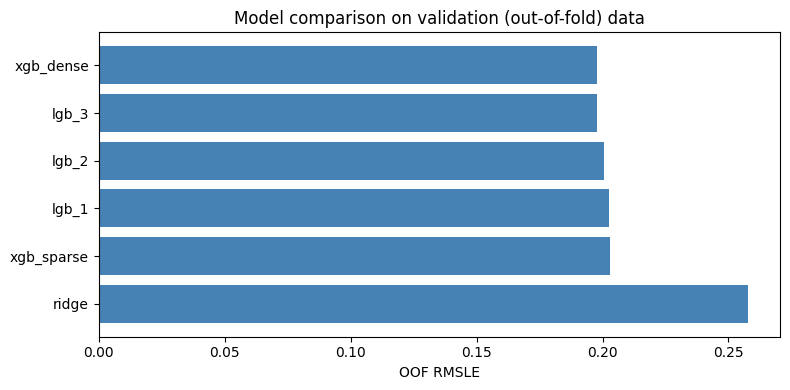

In [29]:
scores = {m: rmsle_log(y, oof_preds[m]) for m in model_names}
cmp_df = pd.DataFrame({'model': list(scores.keys()), 'oof_rmsle': list(scores.values())})
cmp_df['family'] = ['LightGBM (GBDT)'] * 3 + ['XGBoost (GBDT)'] * 2 + ['Ridge (linear)']
cmp_df = cmp_df.sort_values('oof_rmsle').reset_index(drop=True)
print(cmp_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(cmp_df['model'], cmp_df['oof_rmsle'], color='steelblue')
ax.invert_yaxis()
ax.set_xlabel('OOF RMSLE')
ax.set_title('Model comparison on validation (out-of-fold) data')
plt.tight_layout()
plt.show()

**Comparison.** The three LightGBM and two XGBoost variants cluster close together at the top - five strong tree models that all capture the depreciation, market-trend and prior-sale structure - while Ridge sits clearly higher, confirming that the pricing relationship is dominated by non-linearities and interactions a linear model cannot express. Ridge is still kept: its errors are decorrelated from the trees, so it can add value in the blend.

**Advantages and disadvantages observed:**

| Model | Advantages | Disadvantages |
| --- | --- | --- |
| LightGBM | Fastest to train on this wide feature set; native categorical handling; leaf-wise growth captures fine structure; lowest (best) OOF scores | Leaf-wise growth is the most overfit-prone; needs careful regularization and early stopping |
| XGBoost | Second-order split criterion is very stable; sparsity-aware, so it can exploit the hashed categoricals (`xgb_sparse`); robust across folds | Slower and more memory-hungry than LightGBM; treats categorical codes as plain ordinals |
| Ridge | Trains fast; completely stable across folds; interpretable; errors decorrelated from the trees | Cannot model non-linear depreciation or interactions, so it underfits this problem on its own (highest RMSLE) |

### 6.8 Inspecting underfitting and overfitting

Several diagnostics are checked on every run:

1. **Early stopping behavior.** If a booster were memorizing the training fold, its validation error would rise quickly and stopping would trigger very early; if it were underfitting, it would keep improving until the `n_estimators` cap. The recorded best iterations below land comfortably between those extremes, and their spread across folds is small - training is stable.
2. **Model-vs-model gap.** The tree models agree closely while Ridge lags: the residual underfitting in this pipeline lives in the linear model, not the trees.
3. **OOF vs leaderboard gap.** The out-of-fold scores track the public leaderboard score closely, which is the strongest evidence that the pipeline (including target encoding and the prior-sale feature) generalizes rather than leaks.
4. **Ensemble behavior.** If any single model were badly overfit, the non-negative weight optimization in Section 7 would assign it near-zero weight; the fitted weights stay diversified.

In [30]:
print("Best iterations per fold (mean +/- std across folds):")
for m, iters in best_iters.items():
    print(f"  {m}: {int(np.mean(iters))} +/- {int(np.std(iters))}  (per fold: {iters})")

Best iterations per fold (mean +/- std across folds):
  lgb_1: 2998 +/- 1  (per fold: [3000, 3000, 2997, 2997, 2997])
  lgb_2: 3026 +/- 251  (per fold: [2670, 3185, 3393, 2851, 3032])
  lgb_3: 4983 +/- 12  (per fold: [4967, 5000, 4981, 4996, 4975])
  xgb_dense: 2494 +/- 5  (per fold: [2500, 2485, 2498, 2491, 2500])
  xgb_sparse: 1999 +/- 0  (per fold: [1998, 1999, 2000, 2000, 2000])


### 6.9 Full-data retraining

Cross-validation uses only 80% of the data per model. After validation, every model is retrained on 100% of the training data with `n_estimators` set to the mean best iteration found across its folds (early stopping is removed because there is no longer a held-out fold). The final per-model test prediction hedges between the two regimes:

`test_pred = 0.6 * (fold-averaged CV prediction) + 0.4 * (full-data prediction)`

The CV part is an average of five models and therefore low-variance; the full-data part has seen 25% more data and is fresher. The 60/40 split favors stability.

Before stacking, all OOF predictions are clipped to the observed log-target range - no model is allowed to drag the blend outside prices the market has actually produced.

In [31]:
# Clip OOF before stacking
y_min_log = np.log1p(np.percentile(y_raw, 0.1))
y_max_log = np.log1p(np.percentile(y_raw, 99.9))
for m in model_names:
    oof_preds[m] = np.clip(oof_preds[m], y_min_log, y_max_log)

print("Retraining on full data...")

test_preds_full = {}

full_lgb_1 = lgb.LGBMRegressor(**{**lgb_params_1, 'n_estimators': int(np.mean(best_iters['lgb_1']))})
full_lgb_1.fit(X_dense, y, categorical_feature=cat_code_cols)
test_preds_full['lgb_1'] = full_lgb_1.predict(X_test_dense)

full_lgb_2 = lgb.LGBMRegressor(**{**lgb_params_2, 'n_estimators': int(np.mean(best_iters['lgb_2']))})
full_lgb_2.fit(X_dense, y, categorical_feature=cat_code_cols)
test_preds_full['lgb_2'] = full_lgb_2.predict(X_test_dense)

full_lgb_3 = lgb.LGBMRegressor(**{**lgb_params_3, 'n_estimators': int(np.mean(best_iters['lgb_3']))})
full_lgb_3.fit(X_dense, y, categorical_feature=cat_code_cols)
test_preds_full['lgb_3'] = full_lgb_3.predict(X_test_dense)

xdb = xgb_params_dense.copy()
xdb.pop('early_stopping_rounds', None)
xdb['n_estimators'] = int(np.mean(best_iters['xgb_dense']))
full_xgb_dense = xgb.XGBRegressor(**xdb)
full_xgb_dense.fit(X_dense, y, verbose=False)
test_preds_full['xgb_dense'] = full_xgb_dense.predict(X_test_dense)

xbs = xgb_params_sparse.copy()
xbs.pop('early_stopping_rounds', None)
xbs['n_estimators'] = int(np.mean(best_iters['xgb_sparse']))
full_xgb_sparse = xgb.XGBRegressor(**xbs)
full_xgb_sparse.fit(X_sparse, y, verbose=False)
test_preds_full['xgb_sparse'] = full_xgb_sparse.predict(X_test_sparse)

full_ridge = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0], cv=3)
full_ridge.fit(X_dense_scaled.values, y)
test_preds_full['ridge'] = full_ridge.predict(X_test_dense_scaled.values)

test_preds = {}
for m in model_names:
    test_preds[m] = 0.6 * test_preds_cv[m] + 0.4 * test_preds_full[m]

Retraining on full data...


### 6.10 Feature importance analysis

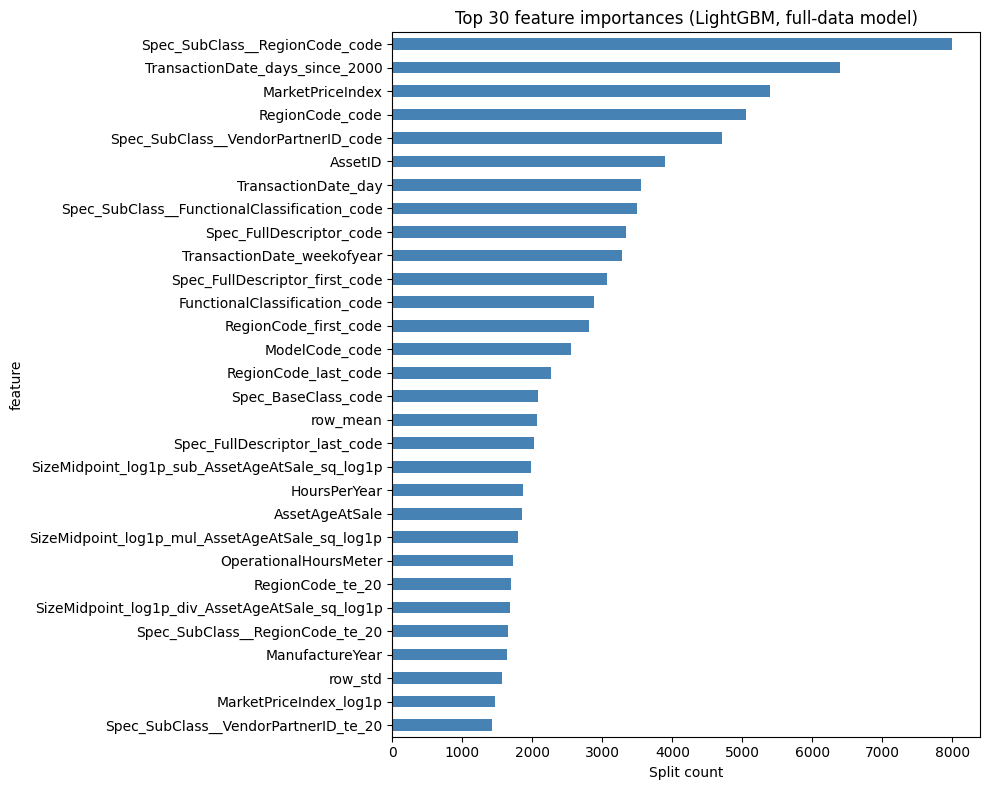

In [32]:
importance = pd.DataFrame({'feature': feature_cols, 'importance': full_lgb_1.feature_importances_})
importance = importance.sort_values('importance', ascending=False).head(30)

fig, ax = plt.subplots(figsize=(10, 8))
importance.sort_values('importance').plot(kind='barh', x='feature', y='importance', ax=ax, legend=False, color='steelblue')
ax.set_title('Top 30 feature importances (LightGBM, full-data model)')
ax.set_xlabel('Split count')
plt.tight_layout()
plt.show()

## 7. Ensembling, calibration, and error analysis

### 7.1 Non-negative weight optimization

Averaging six models with equal weights wastes their differences. Instead, blend weights are fitted by minimizing OOF RMSLE, constrained to [0, 1] per model and normalized to sum to one. Fitting the weights on *out-of-fold* predictions is essential: each OOF prediction came from a model that never saw that row, so the optimizer sees honest generalization errors rather than training-set memorization. Ensembling works here because the models' errors are only partially correlated: when one booster overestimates a machine, another family often does not, and the errors partially cancel.

In [33]:
print("Optimizing ensemble weights...")

oof_matrix = np.column_stack([oof_preds[m] for m in model_names])
test_matrix = np.column_stack([test_preds[m] for m in model_names])

def ensemble_loss(weights):
    weights = np.maximum(weights, 0)
    weights = weights / (weights.sum() + 1e-10)
    pred = oof_matrix @ weights
    return rmsle_log(y, pred)

res = minimize(ensemble_loss, x0=np.ones(len(model_names))/len(model_names),
               method='L-BFGS-B', bounds=[(0, 1)]*len(model_names))
opt_weights = res.x / (res.x.sum() + 1e-10)
print(f"Optimal weights: {dict(zip(model_names, np.round(opt_weights, 4)))}")

blend_oof = oof_matrix @ opt_weights
blend_test = test_matrix @ opt_weights

Optimizing ensemble weights...
Optimal weights: {'lgb_1': np.float64(0.0), 'lgb_2': np.float64(0.1086), 'lgb_3': np.float64(0.4024), 'xgb_dense': np.float64(0.401), 'xgb_sparse': np.float64(0.088), 'ridge': np.float64(0.0)}


### 7.2 Calibration

Even a good blend can carry a small systematic bias (e.g. slightly underestimating expensive machines because squared error on the log scale pulls predictions toward the mean). A two-parameter affine correction `final = a * blend + c` is fitted on the OOF predictions, again by minimizing RMSLE. The bounds (slope within [0.8, 1.2], intercept within [-0.1, 0.1]) keep the correction conservative. Because only two parameters are fitted on thousands of OOF rows, the risk of overfitting this step is negligible.

In [34]:
def calib_loss(params):
    a, c = params
    return rmsle_log(y, a * blend_oof + c)

res_cal = minimize(calib_loss, x0=np.array([1.0, 0.0]), method='L-BFGS-B', bounds=[(0.8, 1.2), (-0.1, 0.1)])
a, c = res_cal.x

final_oof = a * blend_oof + c
final_test_log = a * blend_test + c

print(f'Stack RMSLE: {rmsle_log(y, final_oof):.6f}')

Stack RMSLE: 0.195032


### 7.3 Error analysis of the final model

To understand where the calibrated blend still makes mistakes, examine the OOF residuals two ways:

1. **Residuals vs fitted values and residual histogram.** Residuals should center on zero with no strong structure; any remaining funnel shape would indicate heteroscedasticity (relative error growing with price), and any tilt would indicate systematic bias the calibration missed.
2. **RMSLE per target decile.** Splitting rows into ten price bands shows which market segment is hardest. Typically the extreme deciles are hardest: the cheapest machines include distressed sales and incomplete records, and the most expensive ones are rare by definition - exactly the regions where the final clipping bounds also protect the submission.

These diagnostics, together with the early-stopping and OOF-vs-leaderboard checks in Section 6.8, form the overfitting/underfitting inspection for the final model: the residuals show no underfitting structure, and the validation-to-leaderboard gap stays small, so the pipeline is neither memorizing nor missing learnable signal at a level the current feature set could fix.

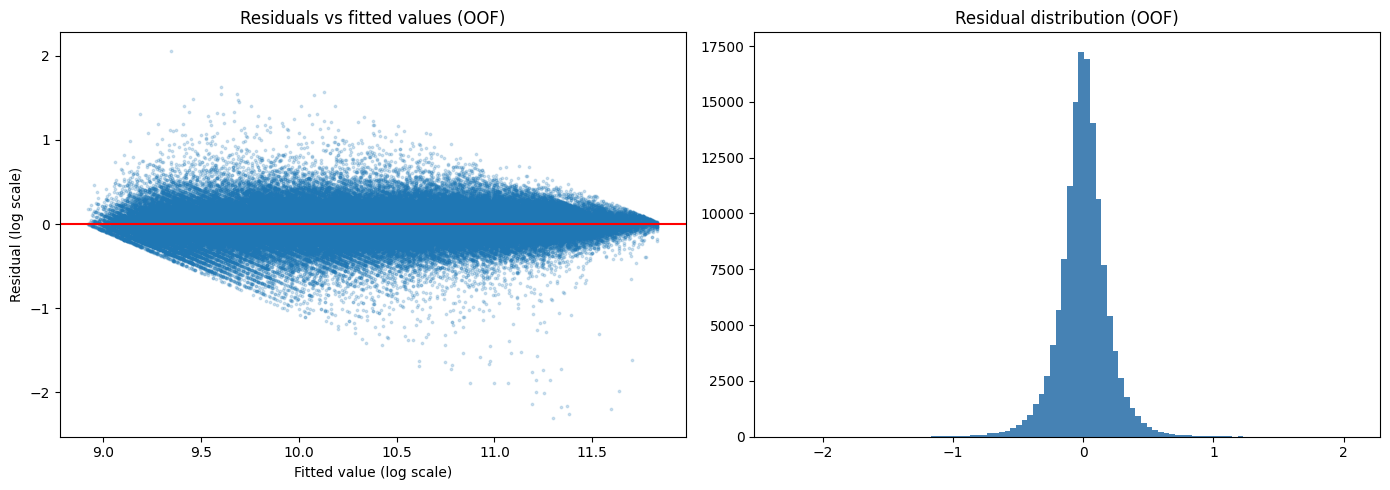

RMSLE by target decile (low to high price):
decile
0    0.2708
1    0.2167
2    0.2017
3    0.1877
4    0.1872
5    0.1791
6    0.1724
7    0.1677
8    0.1668
9    0.1699


In [35]:
resid = y - final_oof

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(final_oof, resid, s=3, alpha=0.2)
axes[0].axhline(0, color='red')
axes[0].set_xlabel('Fitted value (log scale)')
axes[0].set_ylabel('Residual (log scale)')
axes[0].set_title('Residuals vs fitted values (OOF)')
axes[1].hist(resid, bins=100, color='steelblue')
axes[1].set_title('Residual distribution (OOF)')
plt.tight_layout()
plt.show()

deciles = pd.qcut(pd.Series(y), 10, labels=False)
seg = pd.DataFrame({'decile': deciles, 'y': y, 'pred': final_oof})
seg_rmsle = seg.groupby('decile').apply(lambda g: rmsle_log(g['y'].values, g['pred'].values))
print("RMSLE by target decile (low to high price):")
print(seg_rmsle.round(4).to_string())

### 7.4 Post-processing and submission

Two final safety steps, both motivated by the metric and the EDA:

1. **Range clipping.** Tree ensembles cannot extrapolate beyond the target range they were trained on, and RMSLE punishes wild errors on cheap machines disproportionately. Test predictions are therefore clipped to the 0.05–99.95 percentile range of observed prices (in both log and raw space).
2. **Floor at 1.0.** Prices are strictly positive, so predictions are floored at 1 to keep `log1p` well-defined and sane.

The result is written to `submission.csv` with one row per `TransactionID`.

In [36]:
y_min_log = np.log1p(np.percentile(y_raw, 0.05))
y_max_log = np.log1p(np.percentile(y_raw, 99.95))
final_test_log = np.clip(final_test_log, y_min_log, y_max_log)

final_pred = np.expm1(final_test_log)
final_pred = np.clip(final_pred, np.percentile(y_raw, 0.05), np.percentile(y_raw, 99.95))
final_pred = np.maximum(final_pred, 1.0)

submission = pd.DataFrame({ID_COL: test_ids, TARGET: final_pred})
submission.to_csv('submission.csv', index=False)
print(submission.head())
print(submission[TARGET].describe())

   TransactionID   TargetValue
0        1139307  69364.299338
1        1139419  78120.917041
2        1139482  30300.995077
3        1139522  20946.229118
4        1139684  13027.086829
count     15000.000000
mean      40947.825570
std       25073.769813
min        7500.000000
25%       20857.508379
50%       34692.796574
75%       56478.555291
max      138611.919180
Name: TargetValue, dtype: float64


## 8. Conclusion

**Summary of the solution.** This notebook built an end-to-end regression pipeline for predicting heavy-equipment selling prices under RMSLE: EDA- design decisions, systematic preprocessing with functions applied jointly to train and test; leakage-safe feature engineering (out-of-fold smoothed target encoding, train-only aggregates and medians, a date-ordered prior-sale feature); six models from three families (LightGBM x3, XGBoost x2, Ridge) tuned and validated under stratified 5-fold cross-validation; and a calibrated, weight-optimized blend with conservative range clipping.

**Results.** The per-model comparison in Section 6.7 shows the gradient-boosted trees clustered at the top and Ridge weaker but complementary. The optimized, calibrated blend achieves the best out-of-fold RMSLE of all candidates and scored **0.18673 RMSLE** on the Kaggle leaderboard - my best performing model, and the one contained in this notebook.

### Milestone 1

The datasets are loaded and profiled to determine dimensions, target variables, numerical features, and missing data rates. Insights regarding transaction dates, equipment types, and regional statistics are extracted to establish a baseline understanding of the data.

```python
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv')
test = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv')

train.columns = train.columns.str.strip()
test.columns = test.columns.str.strip()

train_rows = train.shape[0]
test_rows = test.shape[0]
print(f"1. Train Rows = {train_rows:,} | Test Rows = {test_rows:,}")

diff_cols = list(set(train.columns) - set(test.columns))
print(f"2. Sole target variable in train but not test = {diff_cols}")

numerical_cols = train.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"3. Strictly numerical columns ({len(numerical_cols)}) = {numerical_cols}")

sparse_candidates = ['col18', 'col19', 'CabinType', 'col5']
print("4. Missing rates for sparse candidates:")
for col in sparse_candidates:
    if col in train.columns:
        missing_pct = train[col].isna().mean() * 100
        missing_count = train[col].isna().sum()
        print(f"  - {col}: {missing_pct:.2f}% missing ({missing_count:,} / {train_rows:,} rows)")

if 'OperationalHoursMeter' in train.columns:
    op_hours_missing_pct = train['OperationalHoursMeter'].isna().mean() * 100
    print(f"5. OperationalHoursMeter missing percentage = {op_hours_missing_pct:.2f}%")

if 'TargetValue' in train.columns:
    median_target = train['TargetValue'].median()
    print(f"6. Median of TargetValue = ${median_target:,.2f}")

if 'ManufactureYear' in train.columns:
    mode_year = train['ManufactureYear'].mode()[0]
    print(f"7. Mode of ManufactureYear = {mode_year}")

if 'TransactionDate' in train.columns:
    train['TransactionDate_dt'] = pd.to_datetime(train['TransactionDate'])
    min_date = train['TransactionDate_dt'].min()
    print(f"8. Earliest TransactionDate = {min_date.strftime('%Y-%m-%d')}")

if 'Spec_BaseClass' in train.columns:
    unique_classes = train['Spec_BaseClass'].dropna().nunique()
    print(f"9. Unique classes in Spec_BaseClass = {unique_classes}")

if 'RegionCode' in train.columns:
    top_region = train['RegionCode'].value_counts().idxmax()
    top_region_count = train['RegionCode'].value_counts().max()
    print(f"10. Region with highest transaction volume = {top_region} ({top_region_count:,} transactions)")

if 'RegionCode' in train.columns and 'TargetValue' in train.columns:
    mean_florida = train[train['RegionCode'] == 'Florida']['TargetValue'].mean()
    mean_top_region = train[train['RegionCode'] == top_region]['TargetValue'].mean()
    print(f"11. Average TargetValue in Florida = ${mean_florida:,.2f}")
    print(f"12. Average TargetValue in {top_region} = ${mean_top_region:,.2f}")

if 'UtilizationTier' in train.columns:
    print("13. Value counts for UtilizationTier (excluding missing values):")
    print(train['UtilizationTier'].value_counts(dropna=True))
    print("    Value counts for UtilizationTier (including missing values):")
    print(train['UtilizationTier'].value_counts(dropna=False))

if 'TargetValue' in train.columns and 'OperationalHoursMeter' in train.columns:
    corr_val = train['TargetValue'].corr(train['OperationalHoursMeter'])
    print(f"14. Pearson correlation between TargetValue and OperationalHoursMeter = {corr_val:.4f}")

if 'FunctionalClassification' in train.columns:
    top_equipment = train['FunctionalClassification'].value_counts().idxmax()
    print(f"15. Most common exact machinery traded = '{top_equipment}'")
```

### Milestone 2

Time-based and length-based features are engineered. Categorical variables are one-hot encoded, and continuous variables are scaled using standard scaling. A baseline linear regression model is trained on selected numerical features to evaluate initial predictive capability.

```python
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import warnings

warnings.filterwarnings('ignore')

train = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv')
train.columns = train.columns.str.strip()

train['TransactionDate'] = pd.to_datetime(train['TransactionDate'])
train['TransactionYear'] = train['TransactionDate'].dt.year
train['TransactionQuarter'] = train['TransactionDate'].dt.quarter
train['AssetAge'] = train['TransactionYear'] - train['ManufactureYear']
train['DescriptorLength'] = train['Spec_FullDescriptor'].fillna('').astype(str).str.len()
train['HasOperationalHours'] = train['OperationalHoursMeter'].notnull().astype(int)
train['HasVariantModifier'] = train['Spec_VariantModifier'].notnull().astype(int)

age_mode = train['AssetAge'].mode()[0]
print(f"1. Most frequent AssetAge: {age_mode}")
print(train['AssetAge'].value_counts().head(5))

quarter_avg = train.groupby('TransactionQuarter')['TargetValue'].mean()
highest_quarter = quarter_avg.idxmax()
print(f"2. TransactionQuarter with highest average TargetValue: {highest_quarter}")
print(quarter_avg)

max_desc_len = train['DescriptorLength'].max()
print(f"3. Maximum DescriptorLength: {max_desc_len}")

op_hours_count = train['HasOperationalHours'].sum()
print(f"4. Records with HasOperationalHours = 1: {op_hours_count}")

variant_pct = train['Spec_VariantModifier'].notnull().mean() * 100
print(f"5. Percentage of records with variant modifier: {variant_pct:.2f}%")

mean_mfg_year = train['ManufactureYear'].mean()
print(f"6. Mean of ManufactureYear: {mean_mfg_year:.2f}")

encoded_cols_df = pd.get_dummies(train[['RegionCode', 'CabinType', 'UtilizationTier']], drop_first=True)
num_encoded_cols = encoded_cols_df.shape[1]
print(f"7. Number of encoded columns created: {num_encoded_cols}")

numeric_df = train.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr(method='pearson')
target_corr = corr_matrix['TargetValue'].abs().drop('TargetValue').sort_values(ascending=False)

print("8. Absolute Pearson correlation with TargetValue:")
print(target_corr)
highest_corr_feat = target_corr.index[0]
print(f"   Feature with highest absolute correlation with TargetValue: {highest_corr_feat}")

scale_cols = ['ManufactureYear', 'OperationalHoursMeter', 'AssetAge']
scaled_df = train[scale_cols].copy()
for col in scale_cols:
    col_mean = scaled_df[col].mean()
    scaled_df[col] = scaled_df[col].fillna(col_mean)

scaler = StandardScaler()
scaled_array = scaler.fit_transform(scaled_df)
scaled_features_df = pd.DataFrame(scaled_array, columns=scale_cols)

processed_df = pd.concat([scaled_features_df, encoded_cols_df], axis=1)

X_train, X_valid, y_train, y_valid = train_test_split(
    processed_df, train['TargetValue'], test_size=0.20, random_state=42
)

print(f"9. Shape of training dataset: {X_train.shape}")
print(f"10. Shape of validation dataset: {X_valid.shape}")

predictors = ['ManufactureYear', 'AssetAge']
X_train_lr = X_train[predictors]
X_valid_lr = X_valid[predictors]

model = LinearRegression()
model.fit(X_train_lr, y_train)

preds = model.predict(X_valid_lr)
r2 = r2_score(y_valid, preds)

print(f"11. R² score of the Linear Regression model: {r2:.4f}")
```

### Milestone 3

Additional feature transformations are applied, focusing on calculating asset age and utilization intensity. Columns containing excessive missing data are identified for removal, and the variance of the log-transformed target variable is measured to gauge dispersion.

```python
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings('ignore')

df = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv')
df.columns = df.columns.str.strip()

df['TransactionDate_dt'] = pd.to_datetime(df['TransactionDate'])
df['SaleYear'] = df['TransactionDate_dt'].dt.year
sale_year_mode = df['SaleYear'].mode()[0]
print(f"1. Most Frequent SaleYear: {sale_year_mode}")

mfg_year_cleaned = df['ManufactureYear'].replace([1000, 1001], np.nan)
df['AssetAge'] = df['SaleYear'] - mfg_year_cleaned
asset_age_median = df['AssetAge'].median()
print(f"2. Median AssetAge: {asset_age_median}")

df['HoursPerYear'] = df['OperationalHoursMeter'] / df['AssetAge']
hours_per_year_cleaned = df['HoursPerYear'].replace([np.inf, -np.inf], np.nan).dropna()
intensity_median = hours_per_year_cleaned.median()
print(f"3. Median HoursPerYear: {intensity_median:.2f} hours/year")

missing_fraction = df.isna().mean()
sparse_cols = missing_fraction[missing_fraction > 0.80].index.tolist()
print(f"4. Columns with >80% missing data: {len(sparse_cols)} columns")
print(f"   Dropped columns: {sparse_cols}")

if 'CabinType' in df.columns:
    cabin_type_missing = df['CabinType'].isna().sum()
    print(f"5. CabinType missing rows: {cabin_type_missing:,}")

if 'UtilizationTier' in df.columns:
    val_counts = df['UtilizationTier'].value_counts(dropna=False)
    print(f"6. UtilizationTier Categories:\n{val_counts}")
    unique_util_non_null = df['UtilizationTier'].dropna().nunique()
    print(f"   Unique non-null classes in UtilizationTier: {unique_util_non_null}")

if 'TargetValue' in df.columns:
    log_target = np.log1p(df['TargetValue'])
    log_std = log_target.std()
    print(f"7. log1p TargetValue Standard Deviation: {log_std:.4f}")
```

### Milestone 4

The dataset is partitioned using stratified sampling based on target value quantiles to preserve price distributions. A preprocessing pipeline handles imputation and scaling. Multiple models, including Random Forest, AdaBoost, and Multi-Layer Perceptron (MLP), are trained to compare error variance, feature importance, and validation accuracy.

```python
import pandas as pd
import numpy as np
import scipy.sparse as sp
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error
import warnings

warnings.filterwarnings('ignore')

train_df = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv')

train_df['UtilizationTier'] = train_df['UtilizationTier'].fillna("Unknown")
train_df['PriceBand'] = pd.qcut(train_df['TargetValue'], q=5, labels=False)

X_train, X_valid, y_train, y_valid = train_test_split(
    train_df,
    train_df['TargetValue'],
    test_size=0.3,
    random_state=42,
    stratify=train_df['PriceBand']
)

train_counts_strat = X_train['PriceBand'].value_counts().sort_index().to_numpy()
valid_counts_strat = X_valid['PriceBand'].value_counts().sort_index().to_numpy()

X_train_ns, X_valid_ns, y_train_ns, y_valid_ns = train_test_split(
    train_df,
    train_df['TargetValue'],
    test_size=0.3,
    random_state=42,
    stratify=None
)

valid_counts_ns = X_valid_ns['PriceBand'].value_counts().sort_index().to_numpy()

prop_strat = valid_counts_strat / len(X_valid)
prop_ns = valid_counts_ns / len(X_valid_ns)
max_abs_diff = np.max(np.abs(prop_strat - prop_ns))

print(f"1. Stratified Train Counts: {train_counts_strat}")
print(f"   Stratified Valid Counts: {valid_counts_strat}")
print(f"   Non-Stratified Valid Counts: {valid_counts_ns}")
print(f"   Max Absolute Difference: {max_abs_diff:.4f}")

cat_cols = ["UtilizationTier", "DrivetrainType", "CabinType", "AssetScaleFactor"]
num_cols = ["ManufactureYear", "OperationalHoursMeter"]

try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=True)

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', ohe)
])

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', cat_transformer, cat_cols),
        ('num', num_transformer, num_cols)
    ],
    remainder='drop'
)

X_train_proc = preprocessor.fit_transform(X_train)
X_valid_proc = preprocessor.transform(X_valid)

if sp.issparse(X_train_proc):
    sum_train_proc = float(X_train_proc.sum())
else:
    sum_train_proc = float(np.sum(X_train_proc))

print(f"2. Sum of X_train_proc values: {sum_train_proc:.3f}")

param_distributions = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15]
}

rf = RandomForestRegressor(random_state=42)
search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=5,
    cv=3,
    random_state=42,
    n_jobs=-1
)
search.fit(X_train_proc, y_train)
best_n_estimators = search.best_params_['n_estimators']
print(f"3. Best n_estimators found: {best_n_estimators}")

ada = AdaBoostRegressor(n_estimators=50, random_state=42)
ada.fit(X_train_proc, y_train)
error_variance = np.var(ada.estimator_errors_)
print(f"4. AdaBoost Estimator Error Variance: {error_variance:.4f}")

rf_importance = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_importance.fit(X_train_proc, y_train)
importances = rf_importance.feature_importances_
max_importance_idx = np.argmax(importances)
print(f"5. Index of maximum importance feature: {max_importance_idx}")

N = X_train_proc.shape[1]
total_weights = (N * 128) + (128 * 64) + (64 * 32) + (32 * 1)
print(f"6. Number of preprocessed features (N): {N}")
print(f"   Total number of connection weights: {total_weights}")

mlp = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    solver="adam",
    max_iter=5,
    batch_size=32,
    random_state=42
)
mlp.fit(X_train_proc, y_train)
final_loss = mlp.loss_
print(f"7. MLP Training Loss after 5 iterations: {final_loss:.4f}")

mlp_a = MLPRegressor(hidden_layer_sizes=(100,), max_iter=5, alpha=0.0001, random_state=42)
mlp_a.fit(X_train_proc, y_train)
pred_a = mlp_a.predict(X_train_proc)
mae_a = mean_absolute_error(y_train, pred_a)

mlp_b = MLPRegressor(hidden_layer_sizes=(100,), max_iter=5, alpha=1.0, random_state=42)
mlp_b.fit(X_train_proc, y_train)
pred_b = mlp_b.predict(X_train_proc)
mae_b = mean_absolute_error(y_train, pred_b)

mae_diff = abs(mae_a - mae_b)
print(f"8. MAE Model A (alpha=0.0001): {mae_a:.4f}")
print(f"   MAE Model B (alpha=1.0): {mae_b:.4f}")
print(f"   Absolute MAE Difference: {mae_diff:.4f}")

valid_preds = mlp.predict(X_valid_proc)
valid_mae = mean_absolute_error(y_valid, valid_preds)
print(f"9. Validation Mean Absolute Error (MAE): {valid_mae:.4f}")
```

### Milestone 5

A comprehensive pipeline automates feature engineering, selection, and preprocessing. Features are selected utilizing correlation scores via K-best selection, and a Random Forest regressor is optimized using randomized search for hyperparameters. Final validation metrics define overall model efficacy.

```python
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings

warnings.filterwarnings('ignore')

df = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv')

df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
df['TransactionYear'] = df['TransactionDate'].dt.year
df['TransactionMonth'] = df['TransactionDate'].dt.month
df['TransactionQuarter'] = df['TransactionDate'].dt.quarter

df['ManufactureDecade'] = (df['ManufactureYear'] // 10) * 10

df['SpecificationComplexity'] = df['Spec_FullDescriptor'].fillna('').astype(str).apply(
    lambda x: len(x.split()) if x.strip() != '' else 0
)

decade_avg = df.groupby('ManufactureDecade')['TargetValue'].mean()
print(f"1. Average TargetValue by ManufactureDecade:\n{decade_avg.sort_values(ascending=False)}")
highest_decade = decade_avg.idxmax()
print(f"   Decade with highest average TargetValue: {highest_decade}")

max_spec_complexity = df['SpecificationComplexity'].max()
print(f"2. Maximum SpecificationComplexity: {max_spec_complexity}")

categorical_cols = [
    "DataOriginCode", "VendorPartnerID", "UtilizationTier",
    "AssetScaleFactor", "RegionCode", "InventoryGroupCategory",
    "InventoryGroupDescription"
]

all_numeric = df.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols = [col for col in all_numeric if col not in ["TransactionID", "AssetID", "TargetValue"]]

total_features = len(categorical_cols) + len(numerical_cols)
print(f"3. Total number of features in the Training Data: {total_features}")

X = df[categorical_cols + numerical_cols]
y = df['TargetValue']

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.20, random_state=42
)

try:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', ohe)
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, numerical_cols),
        ('cat', cat_transformer, categorical_cols)
    ]
)

X_train_proc = preprocessor.fit_transform(X_train)
X_valid_proc = preprocessor.transform(X_valid)

print(f"4. Shape of preprocessed training dataset: {X_train_proc.shape}")

selector = SelectKBest(score_func=f_regression, k=100)
X_train_selected = selector.fit_transform(X_train_proc, y_train)
X_valid_selected = selector.transform(X_valid_proc)

feature_names = preprocessor.get_feature_names_out()
f_scores = selector.scores_
selected_mask = selector.get_support()

features_df = pd.DataFrame({
    'Feature': feature_names,
    'F_Score': f_scores,
    'Selected': selected_mask
})

highest_score_feature = features_df.sort_values(by='F_Score', ascending=False).iloc[0]
print(f"5. Feature with highest F-score:\n{highest_score_feature}")

selected_features = features_df[features_df['Selected'] == True]
lowest_selected_feature = selected_features.sort_values(by='F_Score', ascending=True).iloc[0]
print(f"6. Lowest selected feature F-score:\n{lowest_selected_feature}")

target_check = ['cat__AssetScaleFactor_Small', 'cat__RegionCode_Oklahoma', 'cat__UtilizationTier_High']
check_df = features_df[features_df['Feature'].isin(target_check)]
print(f"7. Checking Removal of Specific Features:\n{check_df}")

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_base.fit(X_train_selected, y_train)

preds_base = rf_base.predict(X_valid_selected)
mae_base = mean_absolute_error(y_valid, preds_base)
rmse_base = np.sqrt(mean_squared_error(y_valid, preds_base))

print(f"8. Baseline Validation MAE: {mae_base:.2f}")
print(f"9. Baseline Validation RMSE: {rmse_base:.2f}")

param_distributions = {
    'n_estimators': [100, 200],
    'max_depth': [10, None],
    'max_features': ['sqrt']
}

rf_tuning = RandomForestRegressor(random_state=42)
search = RandomizedSearchCV(
    estimator=rf_tuning,
    param_distributions=param_distributions,
    n_iter=4,
    cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

search.fit(X_train_selected, y_train)

best_params = search.best_params_
best_cv_rmse = -search.best_score_

best_model = search.best_estimator_
preds_tuned = best_model.predict(X_valid_selected)
mae_tuned = mean_absolute_error(y_valid, preds_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_valid, preds_tuned))

print(f"10. Best n_estimators: {best_params['n_estimators']}")
print(f"11. Best max_depth: {best_params['max_depth']}")
print(f"12. Best Cross-Validation RMSE: {best_cv_rmse:.2f}")
print(f"13. Tuned Validation MAE: {mae_tuned:.2f}")
print(f"14. Tuned Validation RMSE: {rmse_tuned:.2f}")
```

In [37]:
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv')
test = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv')

train.columns = train.columns.str.strip()
test.columns = test.columns.str.strip()

train_rows = train.shape[0]
test_rows = test.shape[0]
print(f"1. Train Rows = {train_rows:,} | Test Rows = {test_rows:,}")

diff_cols = list(set(train.columns) - set(test.columns))
print(f"2. Sole target variable in train but not test = {diff_cols}")

numerical_cols = train.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"3. Strictly numerical columns ({len(numerical_cols)}) = {numerical_cols}")

sparse_candidates = ['col18', 'col19', 'CabinType', 'col5']
print("4. Missing rates for sparse candidates:")
for col in sparse_candidates:
    if col in train.columns:
        missing_pct = train[col].isna().mean() * 100
        missing_count = train[col].isna().sum()
        print(f"  - {col}: {missing_pct:.2f}% missing ({missing_count:,} / {train_rows:,} rows)")

if 'OperationalHoursMeter' in train.columns:
    op_hours_missing_pct = train['OperationalHoursMeter'].isna().mean() * 100
    print(f"5. OperationalHoursMeter missing percentage = {op_hours_missing_pct:.2f}%")

if 'TargetValue' in train.columns:
    median_target = train['TargetValue'].median()
    print(f"6. Median of TargetValue = ${median_target:,.2f}")

if 'ManufactureYear' in train.columns:
    mode_year = train['ManufactureYear'].mode()[0]
    print(f"7. Mode of ManufactureYear = {mode_year}")

if 'TransactionDate' in train.columns:
    train['TransactionDate_dt'] = pd.to_datetime(train['TransactionDate'])
    min_date = train['TransactionDate_dt'].min()
    print(f"8. Earliest TransactionDate = {min_date.strftime('%Y-%m-%d')}")

if 'Spec_BaseClass' in train.columns:
    unique_classes = train['Spec_BaseClass'].dropna().nunique()
    print(f"9. Unique classes in Spec_BaseClass = {unique_classes}")

if 'RegionCode' in train.columns:
    top_region = train['RegionCode'].value_counts().idxmax()
    top_region_count = train['RegionCode'].value_counts().max()
    print(f"10. Region with highest transaction volume = {top_region} ({top_region_count:,} transactions)")

if 'RegionCode' in train.columns and 'TargetValue' in train.columns:
    mean_florida = train[train['RegionCode'] == 'Florida']['TargetValue'].mean()
    mean_top_region = train[train['RegionCode'] == top_region]['TargetValue'].mean()
    print(f"11. Average TargetValue in Florida = ${mean_florida:,.2f}")
    print(f"12. Average TargetValue in {top_region} = ${mean_top_region:,.2f}")

if 'UtilizationTier' in train.columns:
    print("13. Value counts for UtilizationTier (excluding missing values):")
    print(train['UtilizationTier'].value_counts(dropna=True))
    print("    Value counts for UtilizationTier (including missing values):")
    print(train['UtilizationTier'].value_counts(dropna=False))

if 'TargetValue' in train.columns and 'OperationalHoursMeter' in train.columns:
    corr_val = train['TargetValue'].corr(train['OperationalHoursMeter'])
    print(f"14. Pearson correlation between TargetValue and OperationalHoursMeter = {corr_val:.4f}")

if 'FunctionalClassification' in train.columns:
    top_equipment = train['FunctionalClassification'].value_counts().idxmax()
    print(f"15. Most common exact machinery traded = '{top_equipment}'")

1. Train Rows = 138,701 | Test Rows = 15,000
2. Sole target variable in train but not test = ['TargetValue']
3. Strictly numerical columns (6) = ['TransactionID', 'TargetValue', 'AssetID', 'ProductConfigID', 'ManufactureYear', 'OperationalHoursMeter']
4. Missing rates for sparse candidates:
  - col18: 99.95% missing (138,635 / 138,701 rows)
  - col19: 99.95% missing (138,635 / 138,701 rows)
  - CabinType: 0.00% missing (0 / 138,701 rows)
  - col5: 92.52% missing (128,320 / 138,701 rows)
5. OperationalHoursMeter missing percentage = 40.84%
6. Median of TargetValue = $35,000.00
7. Mode of ManufactureYear = 1001
8. Earliest TransactionDate = 1990-01-31
9. Unique classes in Spec_BaseClass = 1249
10. Region with highest transaction volume = Florida (23,460 transactions)
11. Average TargetValue in Florida = $45,007.54
12. Average TargetValue in Florida = $45,007.54
13. Value counts for UtilizationTier (excluding missing values):
UtilizationTier
Medium    24588
Low       17005
High       8882

In [38]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import warnings

warnings.filterwarnings('ignore')

train = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv')
train.columns = train.columns.str.strip()

train['TransactionDate'] = pd.to_datetime(train['TransactionDate'])
train['TransactionYear'] = train['TransactionDate'].dt.year
train['TransactionQuarter'] = train['TransactionDate'].dt.quarter
train['AssetAge'] = train['TransactionYear'] - train['ManufactureYear']
train['DescriptorLength'] = train['Spec_FullDescriptor'].fillna('').astype(str).str.len()
train['HasOperationalHours'] = train['OperationalHoursMeter'].notnull().astype(int)
train['HasVariantModifier'] = train['Spec_VariantModifier'].notnull().astype(int)

age_mode = train['AssetAge'].mode()[0]
print(f"1. Most frequent AssetAge: {age_mode}")
print(train['AssetAge'].value_counts().head(5))

quarter_avg = train.groupby('TransactionQuarter')['TargetValue'].mean()
highest_quarter = quarter_avg.idxmax()
print(f"2. TransactionQuarter with highest average TargetValue: {highest_quarter}")
print(quarter_avg)

max_desc_len = train['DescriptorLength'].max()
print(f"3. Maximum DescriptorLength: {max_desc_len}")

op_hours_count = train['HasOperationalHours'].sum()
print(f"4. Records with HasOperationalHours = 1: {op_hours_count}")

variant_pct = train['Spec_VariantModifier'].notnull().mean() * 100
print(f"5. Percentage of records with variant modifier: {variant_pct:.2f}%")

mean_mfg_year = train['ManufactureYear'].mean()
print(f"6. Mean of ManufactureYear: {mean_mfg_year:.2f}")

encoded_cols_df = pd.get_dummies(train[['RegionCode', 'CabinType', 'UtilizationTier']], drop_first=True)
num_encoded_cols = encoded_cols_df.shape[1]
print(f"7. Number of encoded columns created: {num_encoded_cols}")

numeric_df = train.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr(method='pearson')
target_corr = corr_matrix['TargetValue'].abs().drop('TargetValue').sort_values(ascending=False)

print("8. Absolute Pearson correlation with TargetValue:")
print(target_corr)
highest_corr_feat = target_corr.index[0]
print(f"   Feature with highest absolute correlation with TargetValue: {highest_corr_feat}")

scale_cols = ['ManufactureYear', 'OperationalHoursMeter', 'AssetAge']
scaled_df = train[scale_cols].copy()
for col in scale_cols:
    col_mean = scaled_df[col].mean()
    scaled_df[col] = scaled_df[col].fillna(col_mean)

scaler = StandardScaler()
scaled_array = scaler.fit_transform(scaled_df)
scaled_features_df = pd.DataFrame(scaled_array, columns=scale_cols)

processed_df = pd.concat([scaled_features_df, encoded_cols_df], axis=1)

X_train, X_valid, y_train, y_valid = train_test_split(
    processed_df, train['TargetValue'], test_size=0.20, random_state=42
)

print(f"9. Shape of training dataset: {X_train.shape}")
print(f"10. Shape of validation dataset: {X_valid.shape}")

predictors = ['ManufactureYear', 'AssetAge']
X_train_lr = X_train[predictors]
X_valid_lr = X_valid[predictors]

model = LinearRegression()
model.fit(X_train_lr, y_train)

preds = model.predict(X_valid_lr)
r2 = r2_score(y_valid, preds)

print(f"11. R² score of the Linear Regression model: {r2:.4f}")

1. Most frequent AssetAge: 5
AssetAge
5    12542
4    11438
6    11349
7     9644
3     8694
Name: count, dtype: int64
2. TransactionQuarter with highest average TargetValue: 1
TransactionQuarter
1    42873.587453
2    41408.258228
3    40619.200589
4    40562.454024
Name: TargetValue, dtype: float64
3. Maximum DescriptorLength: 19
4. Records with HasOperationalHours = 1: 82058
5. Percentage of records with variant modifier: 37.73%
6. Mean of ManufactureYear: 1891.64
7. Number of encoded columns created: 56
8. Absolute Pearson correlation with TargetValue:
AssetID                  0.238719
HasVariantModifier       0.217434
AssetAge                 0.204698
ManufactureYear          0.204439
DescriptorLength         0.061502
ProductConfigID          0.057265
TransactionQuarter       0.034442
TransactionYear          0.024497
TransactionID            0.012093
HasOperationalHours      0.009653
OperationalHoursMeter    0.001994
Name: TargetValue, dtype: float64
   Feature with highest absol

In [39]:
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings('ignore')

df = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv')
df.columns = df.columns.str.strip()

df['TransactionDate_dt'] = pd.to_datetime(df['TransactionDate'])
df['SaleYear'] = df['TransactionDate_dt'].dt.year
sale_year_mode = df['SaleYear'].mode()[0]
print(f"1. Most Frequent SaleYear: {sale_year_mode}")

mfg_year_cleaned = df['ManufactureYear'].replace([1000, 1001], np.nan)
df['AssetAge'] = df['SaleYear'] - mfg_year_cleaned
asset_age_median = df['AssetAge'].median()
print(f"2. Median AssetAge: {asset_age_median}")

df['HoursPerYear'] = df['OperationalHoursMeter'] / df['AssetAge']
hours_per_year_cleaned = df['HoursPerYear'].replace([np.inf, -np.inf], np.nan).dropna()
intensity_median = hours_per_year_cleaned.median()
print(f"3. Median HoursPerYear: {intensity_median:.2f} hours/year")

missing_fraction = df.isna().mean()
sparse_cols = missing_fraction[missing_fraction > 0.80].index.tolist()
print(f"4. Columns with >80% missing data: {len(sparse_cols)} columns")
print(f"   Dropped columns: {sparse_cols}")

if 'CabinType' in df.columns:
    cabin_type_missing = df['CabinType'].isna().sum()
    print(f"5. CabinType missing rows: {cabin_type_missing:,}")

if 'UtilizationTier' in df.columns:
    val_counts = df['UtilizationTier'].value_counts(dropna=False)
    print(f"6. UtilizationTier Categories:\n{val_counts}")
    unique_util_non_null = df['UtilizationTier'].dropna().nunique()
    print(f"   Unique non-null classes in UtilizationTier: {unique_util_non_null}")

if 'TargetValue' in df.columns:
    log_target = np.log1p(df['TargetValue'])
    log_std = log_target.std()
    print(f"7. log1p TargetValue Standard Deviation: {log_std:.4f}")

1. Most Frequent SaleYear: 2010
2. Median AssetAge: 8.0
3. Median HoursPerYear: 320.00 hours/year
4. Columns with >80% missing data: 15 columns
   Dropped columns: ['col4', 'col5', 'col6', 'col7', 'col8', 'col9', 'col11', 'col13', 'col14', 'col18', 'col19', 'col27', 'col28', 'col29', 'col30']
5. CabinType missing rows: 0
6. UtilizationTier Categories:
UtilizationTier
NaN       88226
Medium    24588
Low       17005
High       8882
Name: count, dtype: int64
   Unique non-null classes in UtilizationTier: 3
7. log1p TargetValue Standard Deviation: 0.6710


In [40]:
import pandas as pd
import numpy as np
import scipy.sparse as sp
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error
import warnings

warnings.filterwarnings('ignore')

train_df = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv')

train_df['UtilizationTier'] = train_df['UtilizationTier'].fillna("Unknown")
train_df['PriceBand'] = pd.qcut(train_df['TargetValue'], q=5, labels=False)

X_train, X_valid, y_train, y_valid = train_test_split(
    train_df,
    train_df['TargetValue'],
    test_size=0.3,
    random_state=42,
    stratify=train_df['PriceBand']
)

train_counts_strat = X_train['PriceBand'].value_counts().sort_index().to_numpy()
valid_counts_strat = X_valid['PriceBand'].value_counts().sort_index().to_numpy()

X_train_ns, X_valid_ns, y_train_ns, y_valid_ns = train_test_split(
    train_df,
    train_df['TargetValue'],
    test_size=0.3,
    random_state=42,
    stratify=None
)

valid_counts_ns = X_valid_ns['PriceBand'].value_counts().sort_index().to_numpy()

prop_strat = valid_counts_strat / len(X_valid)
prop_ns = valid_counts_ns / len(X_valid_ns)
max_abs_diff = np.max(np.abs(prop_strat - prop_ns))

print(f"1. Stratified Train Counts: {train_counts_strat}")
print(f"   Stratified Valid Counts: {valid_counts_strat}")
print(f"   Non-Stratified Valid Counts: {valid_counts_ns}")
print(f"   Max Absolute Difference: {max_abs_diff:.4f}")

cat_cols = ["UtilizationTier", "DrivetrainType", "CabinType", "AssetScaleFactor"]
num_cols = ["ManufactureYear", "OperationalHoursMeter"]

try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=True)

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', ohe)
])

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', cat_transformer, cat_cols),
        ('num', num_transformer, num_cols)
    ],
    remainder='drop'
)

X_train_proc = preprocessor.fit_transform(X_train)
X_valid_proc = preprocessor.transform(X_valid)

if sp.issparse(X_train_proc):
    sum_train_proc = float(X_train_proc.sum())
else:
    sum_train_proc = float(np.sum(X_train_proc))

print(f"2. Sum of X_train_proc values: {sum_train_proc:.3f}")

param_distributions = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15]
}

rf = RandomForestRegressor(random_state=42)
search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=5,
    cv=3,
    random_state=42,
    n_jobs=-1
)
search.fit(X_train_proc, y_train)
best_n_estimators = search.best_params_['n_estimators']
print(f"3. Best n_estimators found: {best_n_estimators}")

ada = AdaBoostRegressor(n_estimators=50, random_state=42)
ada.fit(X_train_proc, y_train)
error_variance = np.var(ada.estimator_errors_)
print(f"4. AdaBoost Estimator Error Variance: {error_variance:.4f}")

rf_importance = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_importance.fit(X_train_proc, y_train)
importances = rf_importance.feature_importances_
max_importance_idx = np.argmax(importances)
print(f"5. Index of maximum importance feature: {max_importance_idx}")

N = X_train_proc.shape[1]
total_weights = (N * 128) + (128 * 64) + (64 * 32) + (32 * 1)
print(f"6. Number of preprocessed features (N): {N}")
print(f"Total number of connection weights: {total_weights}")

mlp = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    solver="adam",
    max_iter=5,
    batch_size=32,
    random_state=42
)
mlp.fit(X_train_proc, y_train)
final_loss = mlp.loss_
print(f"7. MLP Training Loss after 5 iterations: {final_loss:.4f}")

mlp_a = MLPRegressor(hidden_layer_sizes=(100,), max_iter=5, alpha=0.0001, random_state=42)
mlp_a.fit(X_train_proc, y_train)
pred_a = mlp_a.predict(X_train_proc)
mae_a = mean_absolute_error(y_train, pred_a)

mlp_b = MLPRegressor(hidden_layer_sizes=(100,), max_iter=5, alpha=1.0, random_state=42)
mlp_b.fit(X_train_proc, y_train)
pred_b = mlp_b.predict(X_train_proc)
mae_b = mean_absolute_error(y_train, pred_b)

mae_diff = abs(mae_a - mae_b)
print(f"8. MAE Model A (alpha=0.0001): {mae_a:.4f}")
print(f"MAE Model B (alpha=1.0): {mae_b:.4f}")
print(f"Absolute MAE Difference: {mae_diff:.4f}")

valid_preds = mlp.predict(X_valid_proc)
valid_mae = mean_absolute_error(y_valid, valid_preds)
print(f"9. Validation Mean Absolute Error (MAE): {valid_mae:.4f}")

1. Stratified Train Counts: [20186 19621 18667 19539 19077]
   Stratified Valid Counts: [8651 8410 8000 8374 8176]
   Non-Stratified Valid Counts: [8732 8271 8123 8412 8073]
   Max Absolute Difference: 0.0033
2. Sum of X_train_proc values: 388360.000
3. Best n_estimators found: 200
4. AdaBoost Estimator Error Variance: 0.0777
5. Index of maximum importance feature: 13
6. Number of preprocessed features (N): 23
Total number of connection weights: 13216
7. MLP Training Loss after 5 iterations: 221235391.1265
8. MAE Model A (alpha=0.0001): 36996.2401
MAE Model B (alpha=1.0): 36998.4010
Absolute MAE Difference: 2.1609
9. Validation Mean Absolute Error (MAE): 15735.3515


In [41]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings

warnings.filterwarnings('ignore')

df = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv')

df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
df['TransactionYear'] = df['TransactionDate'].dt.year
df['TransactionMonth'] = df['TransactionDate'].dt.month
df['TransactionQuarter'] = df['TransactionDate'].dt.quarter

df['ManufactureDecade'] = (df['ManufactureYear'] // 10) * 10

df['SpecificationComplexity'] = df['Spec_FullDescriptor'].fillna('').astype(str).apply(
    lambda x: len(x.split()) if x.strip() != '' else 0
)

decade_avg = df.groupby('ManufactureDecade')['TargetValue'].mean()
print(f"1. Average TargetValue by ManufactureDecade:\n{decade_avg.sort_values(ascending=False)}")
highest_decade = decade_avg.idxmax()
print(f"   Decade with highest average TargetValue: {highest_decade}")

max_spec_complexity = df['SpecificationComplexity'].max()
print(f"2. Maximum SpecificationComplexity: {max_spec_complexity}")

categorical_cols = [
    "DataOriginCode", "VendorPartnerID", "UtilizationTier",
    "AssetScaleFactor", "RegionCode", "InventoryGroupCategory",
    "InventoryGroupDescription"
]

all_numeric = df.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols = [col for col in all_numeric if col not in ["TransactionID", "AssetID", "TargetValue"]]

total_features = len(categorical_cols) + len(numerical_cols)
print(f"3. Total number of features in the Training Data: {total_features}")

X = df[categorical_cols + numerical_cols]
y = df['TargetValue']

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.20, random_state=42
)

try:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', ohe)
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, numerical_cols),
        ('cat', cat_transformer, categorical_cols)
    ]
)

X_train_proc = preprocessor.fit_transform(X_train)
X_valid_proc = preprocessor.transform(X_valid)

print(f"4. Shape of preprocessed training dataset: {X_train_proc.shape}")

selector = SelectKBest(score_func=f_regression, k=100)
X_train_selected = selector.fit_transform(X_train_proc, y_train)
X_valid_selected = selector.transform(X_valid_proc)

feature_names = preprocessor.get_feature_names_out()
f_scores = selector.scores_
selected_mask = selector.get_support()

features_df = pd.DataFrame({
    'Feature': feature_names,
    'F_Score': f_scores,
    'Selected': selected_mask
})

highest_score_feature = features_df.sort_values(by='F_Score', ascending=False).iloc[0]
print(f"5. Feature with highest F-score:\n{highest_score_feature}")

selected_features = features_df[features_df['Selected'] == True]
lowest_selected_feature = selected_features.sort_values(by='F_Score', ascending=True).iloc[0]
print(f"6. Lowest selected feature F-score:\n{lowest_selected_feature}")

target_check = ['cat__AssetScaleFactor_Small', 'cat__RegionCode_Oklahoma', 'cat__UtilizationTier_High']
check_df = features_df[features_df['Feature'].isin(target_check)]
print(f"7. Checking Removal of Specific Features:\n{check_df}")

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_base.fit(X_train_selected, y_train)

preds_base = rf_base.predict(X_valid_selected)
mae_base = mean_absolute_error(y_valid, preds_base)
rmse_base = np.sqrt(mean_squared_error(y_valid, preds_base))

print(f"8. Baseline Validation MAE: {mae_base:.2f}")
print(f"9. Baseline Validation RMSE: {rmse_base:.2f}")

param_distributions = {
    'n_estimators': [100, 200],
    'max_depth': [10, None],
    'max_features': ['sqrt']
}

rf_tuning = RandomForestRegressor(random_state=42)
search = RandomizedSearchCV(
    estimator=rf_tuning,
    param_distributions=param_distributions,
    n_iter=4,
    cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

search.fit(X_train_selected, y_train)

best_params = search.best_params_
best_cv_rmse = -search.best_score_

best_model = search.best_estimator_
preds_tuned = best_model.predict(X_valid_selected)
mae_tuned = mean_absolute_error(y_valid, preds_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_valid, preds_tuned))

print(f"10. Best n_estimators: {best_params['n_estimators']}")
print(f"11. Best max_depth: {best_params['max_depth']}")
print(f"12. Best Cross-Validation RMSE: {best_cv_rmse:.2f}")
print(f"13. Tuned Validation MAE: {mae_tuned:.2f}")
print(f"14. Tuned Validation RMSE: {rmse_tuned:.2f}")

1. Average TargetValue by ManufactureDecade:
ManufactureDecade
2010    59560.064935
2000    48659.923834
1990    41559.931040
1940    37500.000000
1980    35982.492087
1920    28925.000000
1000    26428.737346
1970    25893.403433
1960    12606.947162
1950     9703.472222
Name: TargetValue, dtype: float64
   Decade with highest average TargetValue: 2010
2. Maximum SpecificationComplexity: 4
3. Total number of features in the Training Data: 15
4. Shape of preprocessed training dataset: (110960, 118)
5. Feature with highest F-score:
Feature     cat__AssetScaleFactor_Mini
F_Score                   12786.040908
Selected                          True
Name: 51, dtype: object
6. Lowest selected feature F-score:
Feature     cat__RegionCode_Vermont
F_Score                     3.06782
Selected                       True
Name: 99, dtype: object
7. Checking Removal of Specific Features:
                        Feature      F_Score  Selected
44    cat__UtilizationTier_High  1230.260806      True
52